In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 7,
    "figure.constrained_layout.use": True,
})

ALGO_SHORT = {
    "ModifiedLogPartitionVarianceGFlowNet": "ModLPV",
    "LogPartitionVarianceGFlowNet": "LPV",
    "TBGFlowNet": "TB",
    "ModifiedTBGFlowNet": "ModTB",
}
ALGO_ORDER = ["TB", "ModTB", "LPV", "ModLPV"]
COLORS = {"TB": "C0", "ModTB": "C1", "LPV": "C2", "ModLPV": "C3"}
RANK_STYLES = {1: "-", 2: "--", 3: ":"}
RANK_ALPHAS = {1: 1.0, 2: 1.0, 3: 1.0}
ENV_NAMES = {
    "original": "Original",
    "bitwise_xor": "Bitwise XOR",
    "multiplicative_coprime": "Multiplicative Coprime",
    "cosine": "Cosine",
}

confirm_dir = Path("optuna_results/confirm")

# --- Load all CSVs from the confirm directory ---
frames = []
for algo_env_dir in sorted(confirm_dir.iterdir()):
    if not algo_env_dir.is_dir():
        continue
    for rank_dir in sorted(algo_env_dir.iterdir()):
        if not rank_dir.is_dir():
            continue
        rank_name = rank_dir.name  # e.g. rank1_trial9
        rank_num = int(rank_name.split("_")[0].replace("rank", ""))
        # Load config for HP values
        config_files = list(rank_dir.glob("*_config.json"))
        if not config_files:
            continue
        with open(config_files[0]) as f:
            cfg = json.load(f)
        hp = cfg["config_snapshot"]["config"]

        csv_files = list(rank_dir.glob("*_results.csv"))
        if not csv_files:
            continue
        df = pd.read_csv(csv_files[0])
        df["rank"] = rank_num
        df["lr"] = hp.get("lr")
        df["beta2"] = hp.get("beta2")
        df["grad_clip_max_norm"] = hp.get("grad_clip_max_norm")
        df["lr_logz_multiplier"] = hp.get("lr_logz_multiplier")
        frames.append(df)

ts = pd.concat(frames, ignore_index=True)
ts["algo"] = ts["algorithm"].map(ALGO_SHORT)
ts["l1_finite"] = ts["l1_dist"].replace([np.inf, -np.inf], np.nan)
ts["jsd_finite"] = ts["jsd"].replace([np.inf, -np.inf], np.nan)

# Comparable loss: use loss_unnormalized for Modified algos (puts them on the same scale as non-modified)
ts["comparable_loss"] = ts["loss_unnormalized"].where(ts["loss_unnormalized"].notna(), ts["loss"])

HP_COLS = ["lr", "beta2", "grad_clip_max_norm"]
CONFIG_COLS = ["environment", "algo", "rank"]

env_list = sorted(ts["environment"].unique())

print(f"Loaded {ts.shape[0]:,} rows — {ts['algo'].nunique()} algorithms, "
      f"{ts['environment'].nunique()} environments, 3 ranks x 5 seeds each")
print(f"Environments: {env_list}")
print(f"Algorithms: {ALGO_ORDER}")

Loaded 960,000 rows — 4 algorithms, 4 environments, 3 ranks x 5 seeds each
Environments: ['bitwise_xor', 'cosine', 'multiplicative_coprime', 'original']
Algorithms: ['TB', 'ModTB', 'LPV', 'ModLPV']


## Best L1 distance by algorithm and environment

For each (algorithm, environment), the top-3 Optuna configs are confirmed with 5 seeds each. Reported as mean ± std of best L1 across seeds.

In [2]:
# Best L1 per (config, seed) — take minimum L1 achieved during training
best_l1_per_seed = (
    ts.groupby(CONFIG_COLS + ["seed"])["l1_finite"]
    .min()
    .reset_index(name="best_l1")
)

# Aggregate across seeds per config
config_stats = (
    best_l1_per_seed.groupby(CONFIG_COLS)["best_l1"]
    .agg(mean_l1="mean", std_l1="std", n_seeds="count")
    .reset_index()
)

# Display all 3 ranks as a formatted table
display_rows = []
for _, row in config_stats.iterrows():
    display_rows.append({
        "environment": row["environment"],
        "algo": row["algo"],
        "rank": int(row["rank"]),
        "L1 (mean ± std)": f"{row['mean_l1']:.4f} ± {row['std_l1']:.4f}",
        "mean_l1": row["mean_l1"],
    })
display_df = pd.DataFrame(display_rows)
display_df["algo"] = pd.Categorical(display_df["algo"], categories=ALGO_ORDER, ordered=True)
display_df = display_df.sort_values(["environment", "algo", "rank"])

print("Best L1 distance: mean ± std across 5 seeds (lower = better)")
display_df[["environment", "algo", "rank", "L1 (mean ± std)"]].style.hide(axis="index").background_gradient(
    subset=["rank"], cmap="Greens_r", vmin=0, vmax=4
)

Best L1 distance: mean ± std across 5 seeds (lower = better)


environment,algo,rank,L1 (mean ± std)
bitwise_xor,TB,1,1.6609 ± 0.1603
bitwise_xor,TB,2,1.6047 ± 0.2417
bitwise_xor,TB,3,1.6794 ± 0.1662
bitwise_xor,ModTB,1,1.1980 ± 0.0743
bitwise_xor,ModTB,2,1.2559 ± 0.0722
bitwise_xor,ModTB,3,1.2005 ± 0.0588
bitwise_xor,LPV,1,1.3769 ± 0.2859
bitwise_xor,LPV,2,1.5078 ± 0.1907
bitwise_xor,LPV,3,1.3880 ± 0.2805
bitwise_xor,ModLPV,1,1.2082 ± 0.0567


## Consistency across top-3 configs

How much do results vary across the 3 best configs found by Optuna? Small spread = robust hyperparameter selection.

In [3]:
# Show mean L1 for all 3 ranks side by side
rank_pivot = config_stats.pivot_table(
    index=["environment", "algo"], columns="rank", values="mean_l1"
)
rank_pivot.columns = [f"Rank {r}" for r in rank_pivot.columns]
rank_pivot = rank_pivot.reset_index()
rank_pivot["algo"] = pd.Categorical(rank_pivot["algo"], categories=ALGO_ORDER, ordered=True)
rank_pivot = rank_pivot.sort_values(["environment", "algo"])

print("Mean L1 distance across 5 seeds, by rank (config selection from Optuna):")
rank_pivot.style.format({c: "{:.4f}" for c in rank_pivot.columns if c.startswith("Rank")}, na_rep="—")

Mean L1 distance across 5 seeds, by rank (config selection from Optuna):


,environment,algo,Rank 1,Rank 2,Rank 3
3,bitwise_xor,TB,1.6609,1.6047,1.6794
2,bitwise_xor,ModTB,1.1980,1.2559,1.2005
0,bitwise_xor,LPV,1.3769,1.5078,1.3880
1,bitwise_xor,ModLPV,1.2082,1.0116,0.9077
7,cosine,TB,0.7533,1.0684,1.0660
6,cosine,ModTB,0.4476,0.4471,0.4471
4,cosine,LPV,0.4475,0.4473,0.4477
5,cosine,ModLPV,0.4475,0.4471,0.4475
11,multiplicative_coprime,TB,0.5071,0.5054,0.1368
10,multiplicative_coprime,ModTB,0.1374,0.1374,0.5106


## L1 distance over training (top-3 configs per algorithm)

Solid = rank 1, dashed = rank 2, dotted = rank 3. Faint traces show individual seeds; bold line is the mean across 5 seeds.

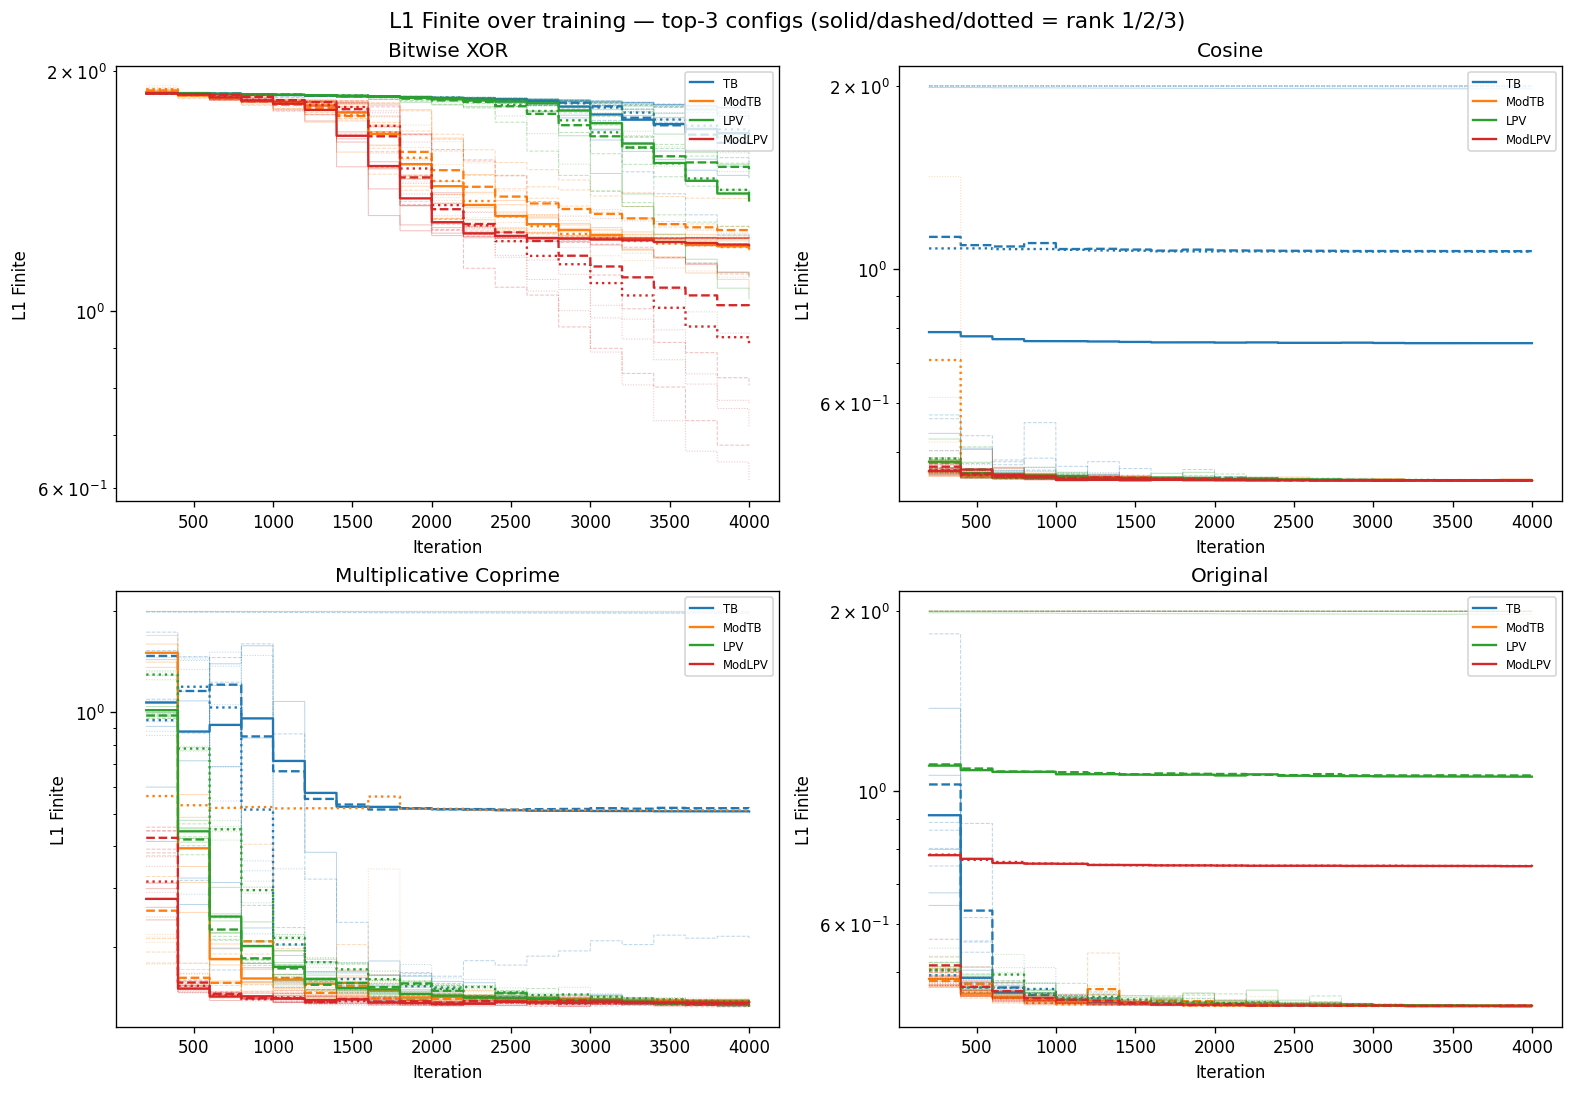

In [4]:
def plot_metric_over_time(ts, metric, n_ranks=3):

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    for ax, env in zip(axes.flat, env_list):

        assert 1 <= n_ranks <= 3, "Expected n_ranks to be between 1 and 3"

        for algo in ALGO_ORDER:
            for rank in range(1, n_ranks + 1):
                ad = ts[(ts["environment"] == env) & (ts["algo"] == algo) & (ts["rank"] == rank)]
                ad = ad[ad[metric].notna()]
                if ad.empty:
                    continue
                # Individual seed traces
                for seed in ad["seed"].unique():
                    seed_data = ad[ad["seed"] == seed].sort_values("iteration")
                    ax.plot(seed_data["iteration"], seed_data[metric],
                            color=COLORS[algo], linestyle=RANK_STYLES[rank],
                            alpha=0.3 * RANK_ALPHAS[rank], linewidth=0.6)
                # Mean trace
                grouped = ad.groupby("iteration")[metric].mean()
                label = algo if rank == 1 else None
                ax.plot(grouped.index, grouped.values,
                        label=label, color=COLORS[algo],
                        linestyle=RANK_STYLES[rank], alpha=RANK_ALPHAS[rank], linewidth=1.4)

        ax.set_title(ENV_NAMES[env])
        ax.set_xlabel("Iteration")
        ax.set_ylabel(metric.replace("_", " ").title())
        ax.set_yscale("log")
        ax.legend(loc="upper right")

    fig.suptitle(f"{metric.replace('_', ' ').title()} over training — top-{n_ranks} configs (solid/dashed/dotted = rank 1/2/3)", fontsize=13)
    plt.show()

plot_metric_over_time(ts, "l1_finite", 3)

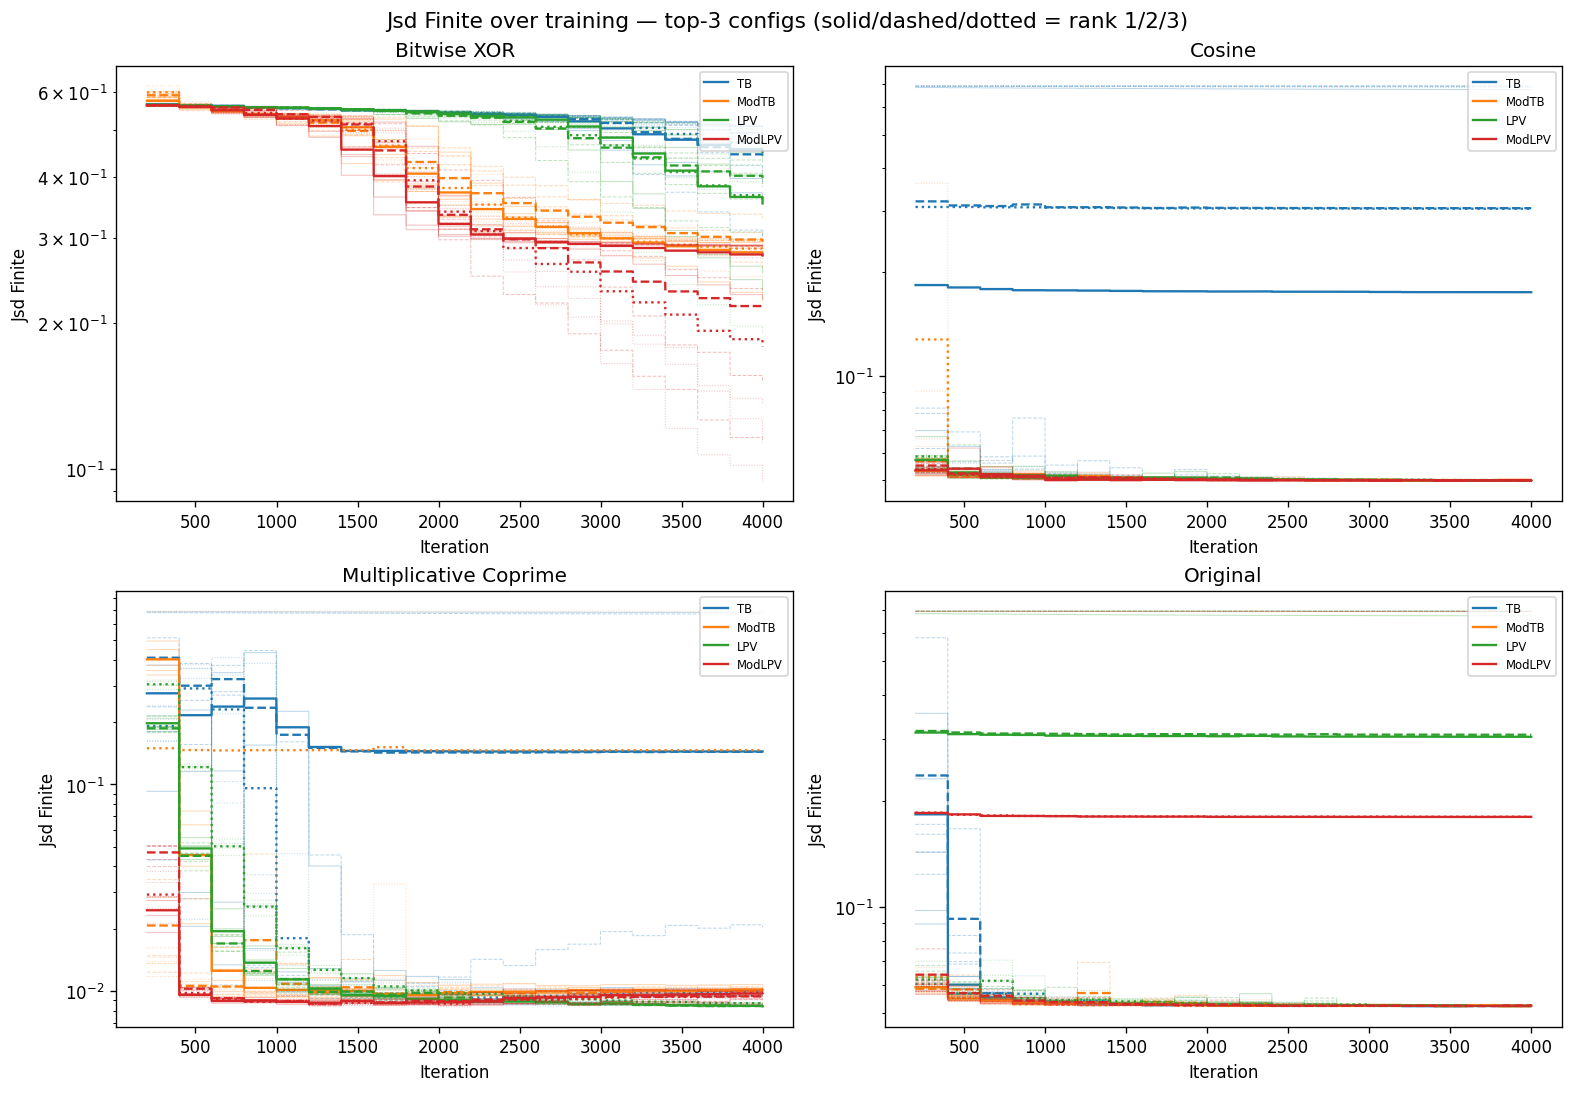

In [5]:
plot_metric_over_time(ts, "jsd_finite", 3)

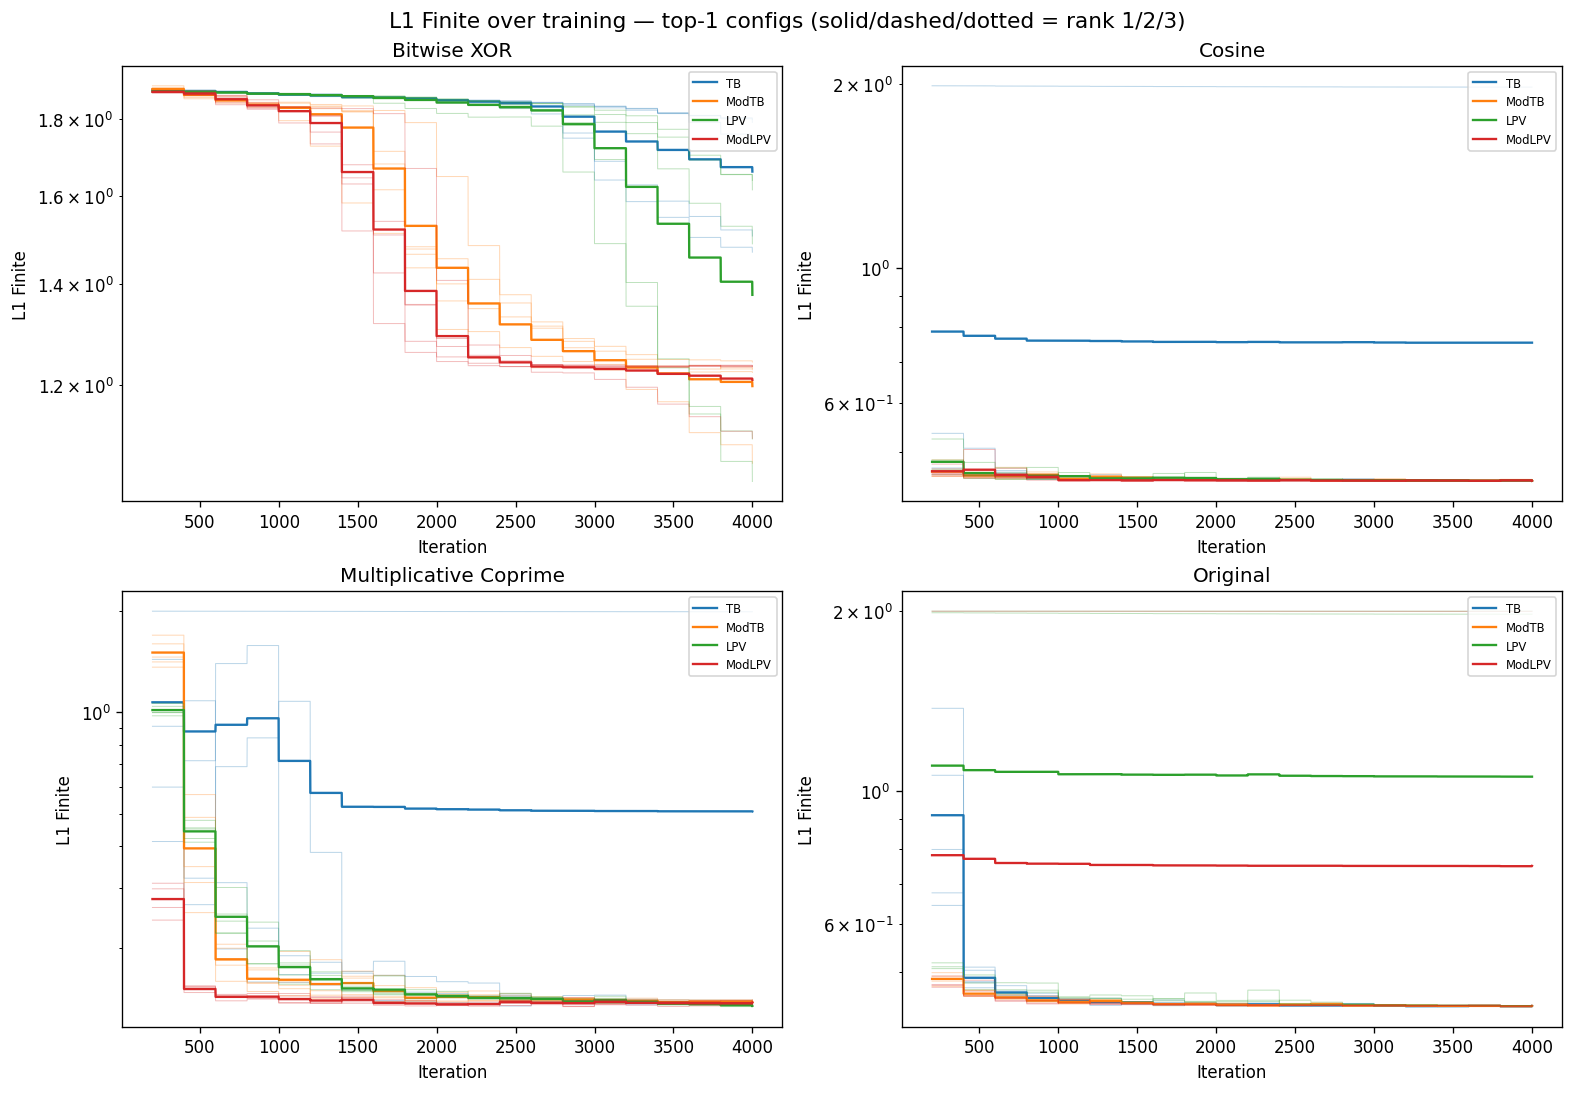

In [6]:
plot_metric_over_time(ts, "l1_finite", 1)

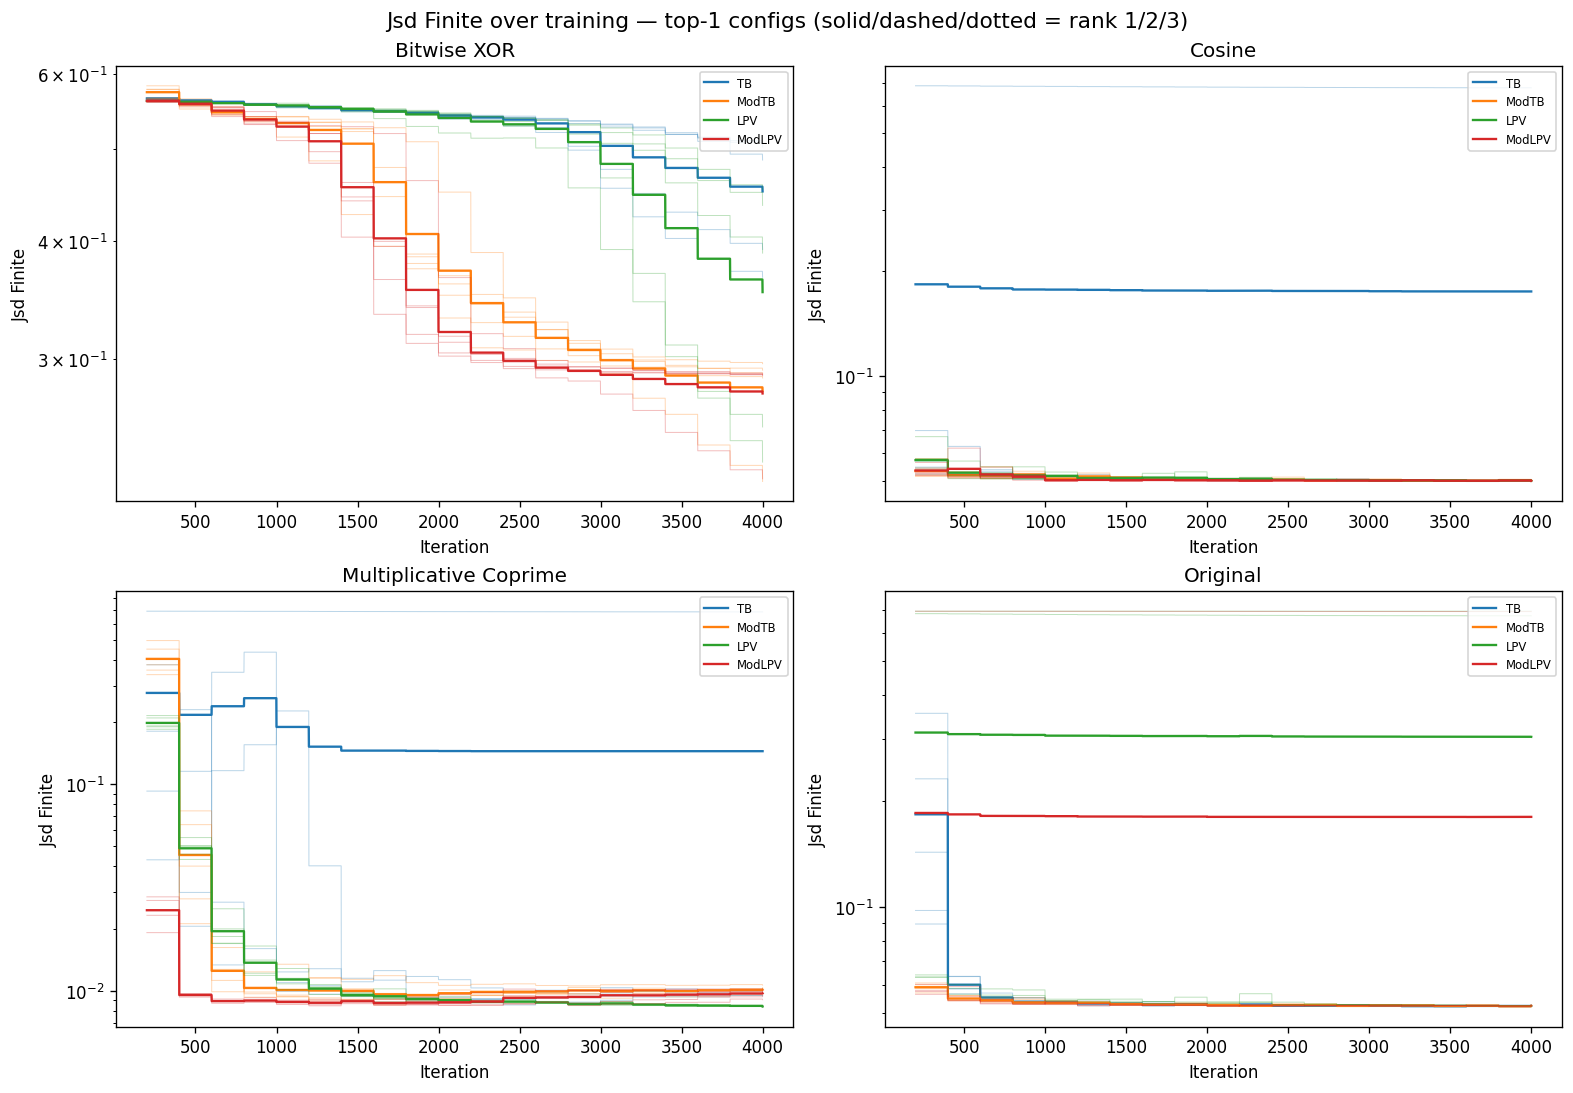

In [7]:
plot_metric_over_time(ts, "jsd_finite", 1)

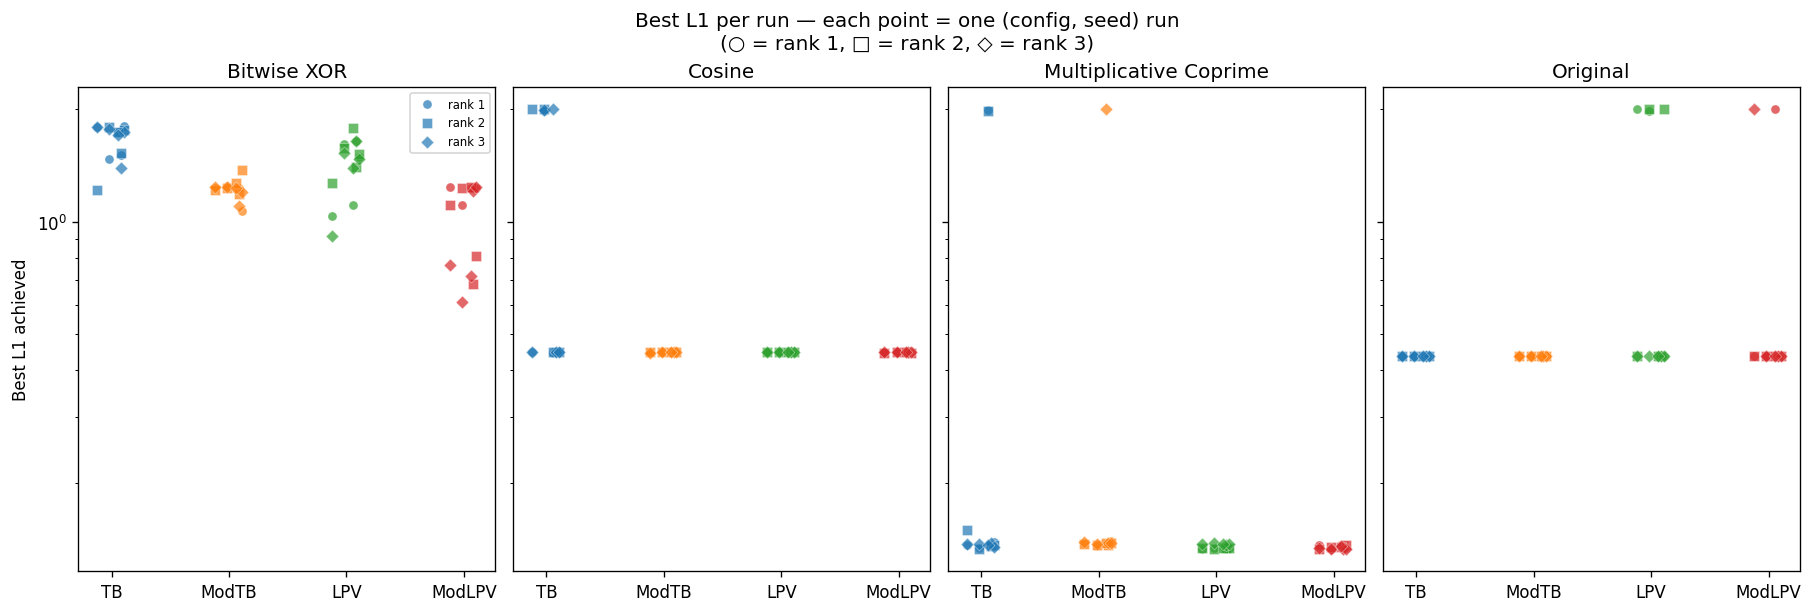

In [8]:
# 1. Strip/beeswarm plot of best L1 achieved per (config, seed)
fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharey=True)

rank_markers = {1: "o", 2: "s", 3: "D"}

for ax, env in zip(axes.flat, env_list):
    for i, algo in enumerate(ALGO_ORDER):
        for rank in [1, 2, 3]:
            sub = best_l1_per_seed[
                (best_l1_per_seed["environment"] == env)
                & (best_l1_per_seed["algo"] == algo)
                & (best_l1_per_seed["rank"] == rank)
            ]
            if sub.empty:
                continue
            jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(sub))
            ax.scatter(
                i + jitter, sub["best_l1"],
                color=COLORS[algo], marker=rank_markers[rank],
                s=30, alpha=0.7, edgecolors="white", linewidths=0.3,
                label=f"rank {rank}" if i == 0 else None,
            )
    ax.set_xticks(range(len(ALGO_ORDER)))
    ax.set_xticklabels(ALGO_ORDER)
    ax.set_title(ENV_NAMES[env])
    ax.set_yscale("log")
    if ax == axes[0]:
        ax.set_ylabel("Best L1 achieved")
        ax.legend(fontsize=7, loc="upper right")

fig.suptitle("Best L1 per run — each point = one (config, seed) run\n(○ = rank 1, □ = rank 2, ◇ = rank 3)", fontsize=12)
plt.show()

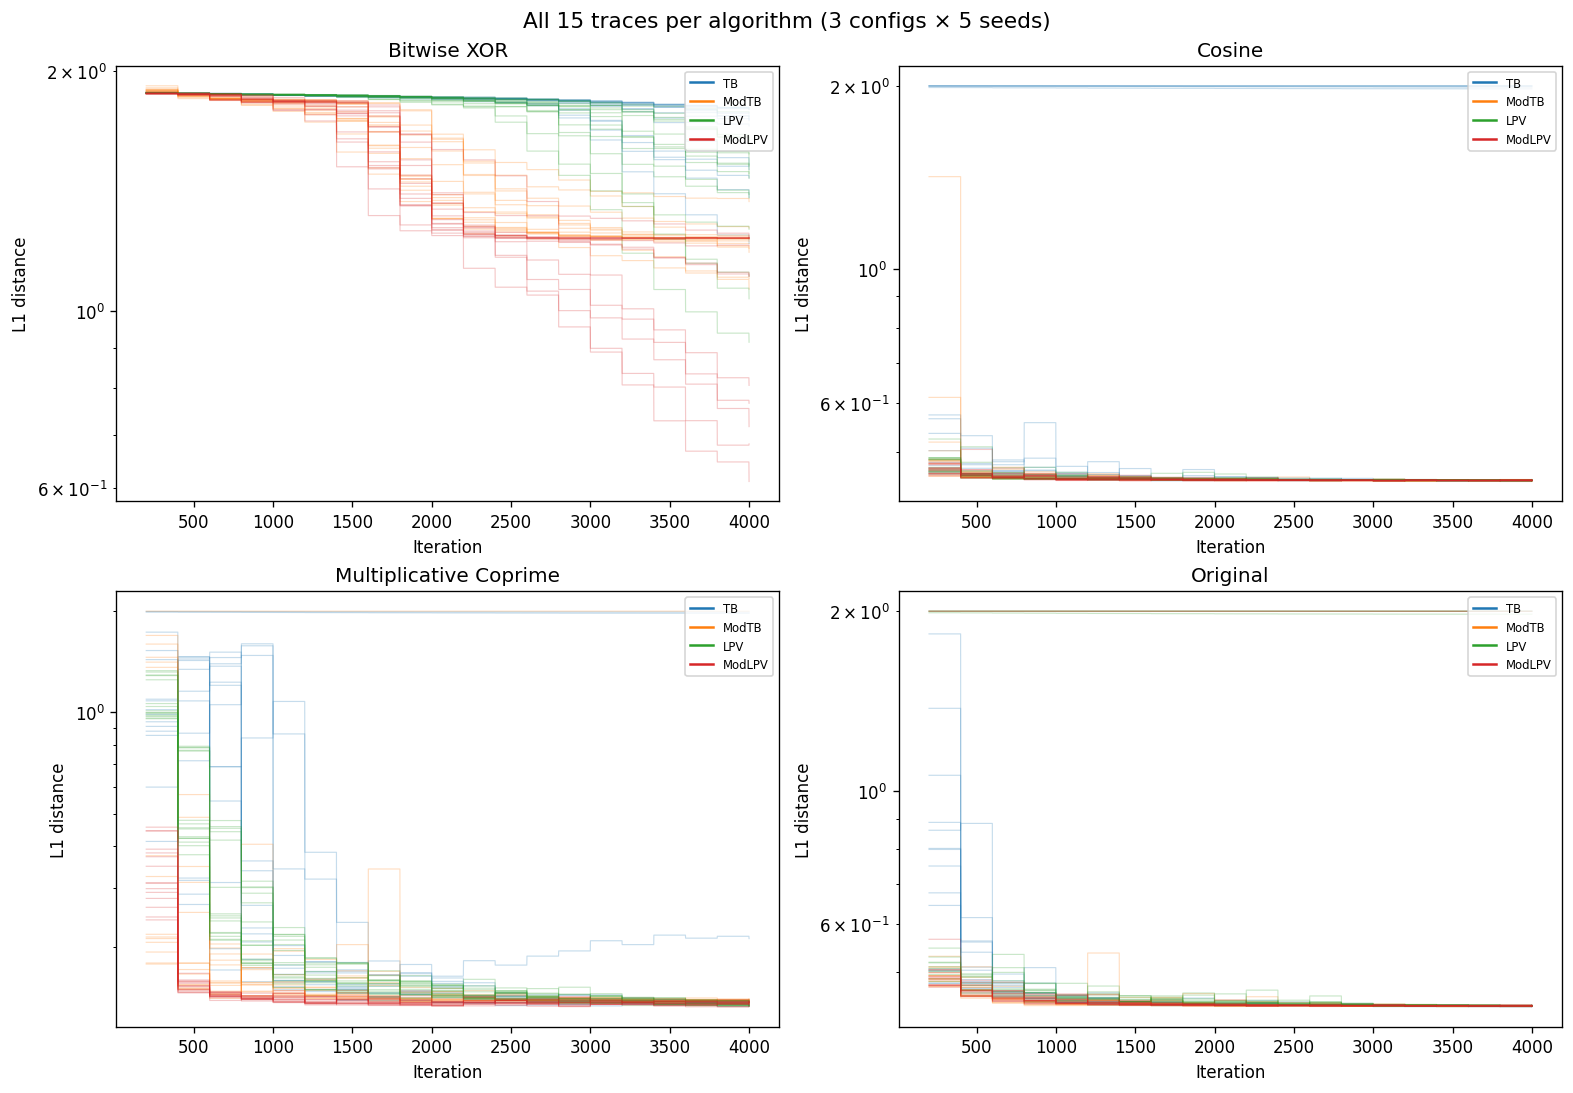

In [9]:
# 2. All 15 traces overlaid per algo (color = algorithm, transparency reveals density)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, env in zip(axes.flat, env_list):
    for algo in ALGO_ORDER:
        ad = ts[(ts["environment"] == env) & (ts["algo"] == algo)]
        ad = ad[ad["l1_finite"].notna()]
        if ad.empty:
            continue
        for (rank, seed), group in ad.groupby(["rank", "seed"]):
            group = group.sort_values("iteration")
            ax.plot(group["iteration"], group["l1_finite"],
                    color=COLORS[algo], alpha=0.25, linewidth=0.7)
        # Add a single label entry via an invisible line
        ax.plot([], [], color=COLORS[algo], linewidth=1.5, label=algo)

    ax.set_title(ENV_NAMES[env])
    ax.set_xlabel("Iteration")
    ax.set_ylabel("L1 distance")
    ax.set_yscale("log")
    ax.legend(loc="upper right")

fig.suptitle("All 15 traces per algorithm (3 configs × 5 seeds)", fontsize=13)
plt.show()

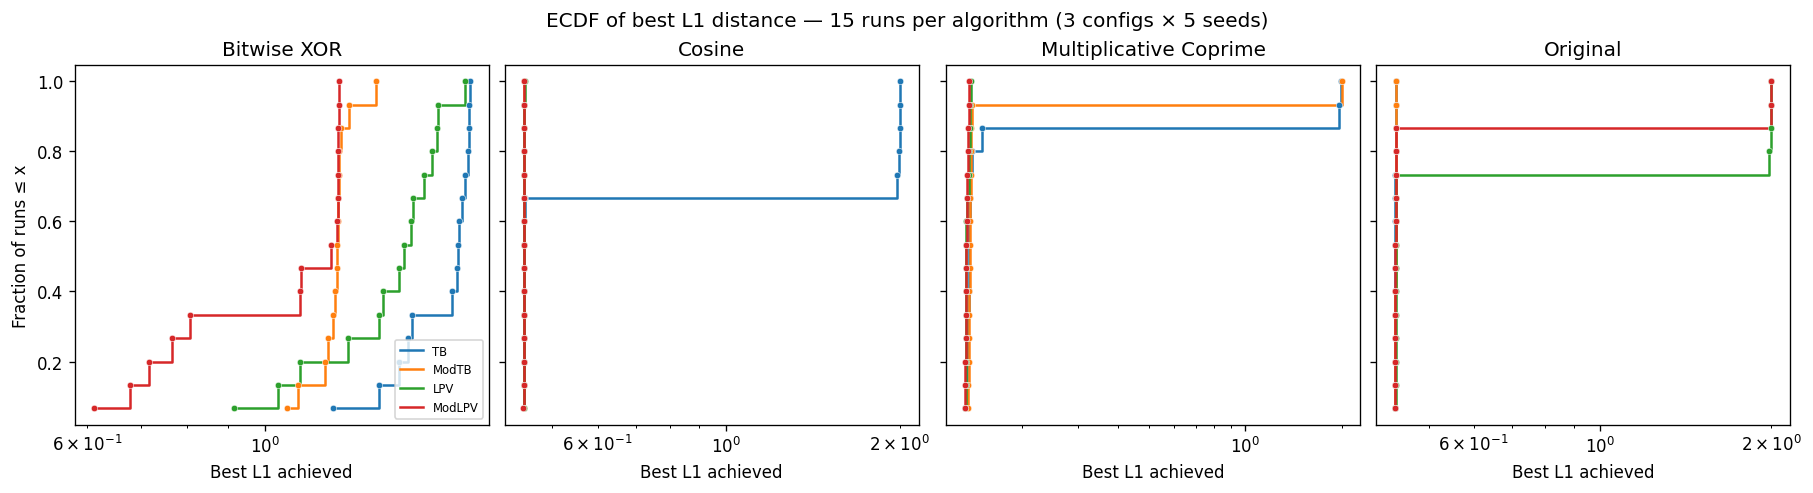

In [11]:
# 4. ECDF of best L1 achieved — "what fraction of runs reach L1 < x?"
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)

for ax, env in zip(axes.flat, env_list):
    for algo in ALGO_ORDER:
        sub = best_l1_per_seed[
            (best_l1_per_seed["environment"] == env)
            & (best_l1_per_seed["algo"] == algo)
        ]
        if sub.empty:
            continue
        vals = np.sort(sub["best_l1"].values)
        ecdf = np.arange(1, len(vals) + 1) / len(vals)
        ax.step(vals, ecdf, where="post", color=COLORS[algo], linewidth=1.5, label=algo)
        # Show individual points
        ax.scatter(vals, ecdf, color=COLORS[algo], s=15, zorder=5, edgecolors="white", linewidths=0.3)

    ax.set_title(ENV_NAMES[env])
    ax.set_xscale("log")
    ax.set_xlabel("Best L1 achieved")
    if ax == axes[0]:
        ax.set_ylabel("Fraction of runs ≤ x")
        ax.legend(fontsize=7, loc="lower right")

fig.suptitle("ECDF of best L1 distance — 15 runs per algorithm (3 configs × 5 seeds)", fontsize=12)
plt.show()

## Mode discovery over training (top-3 configs)

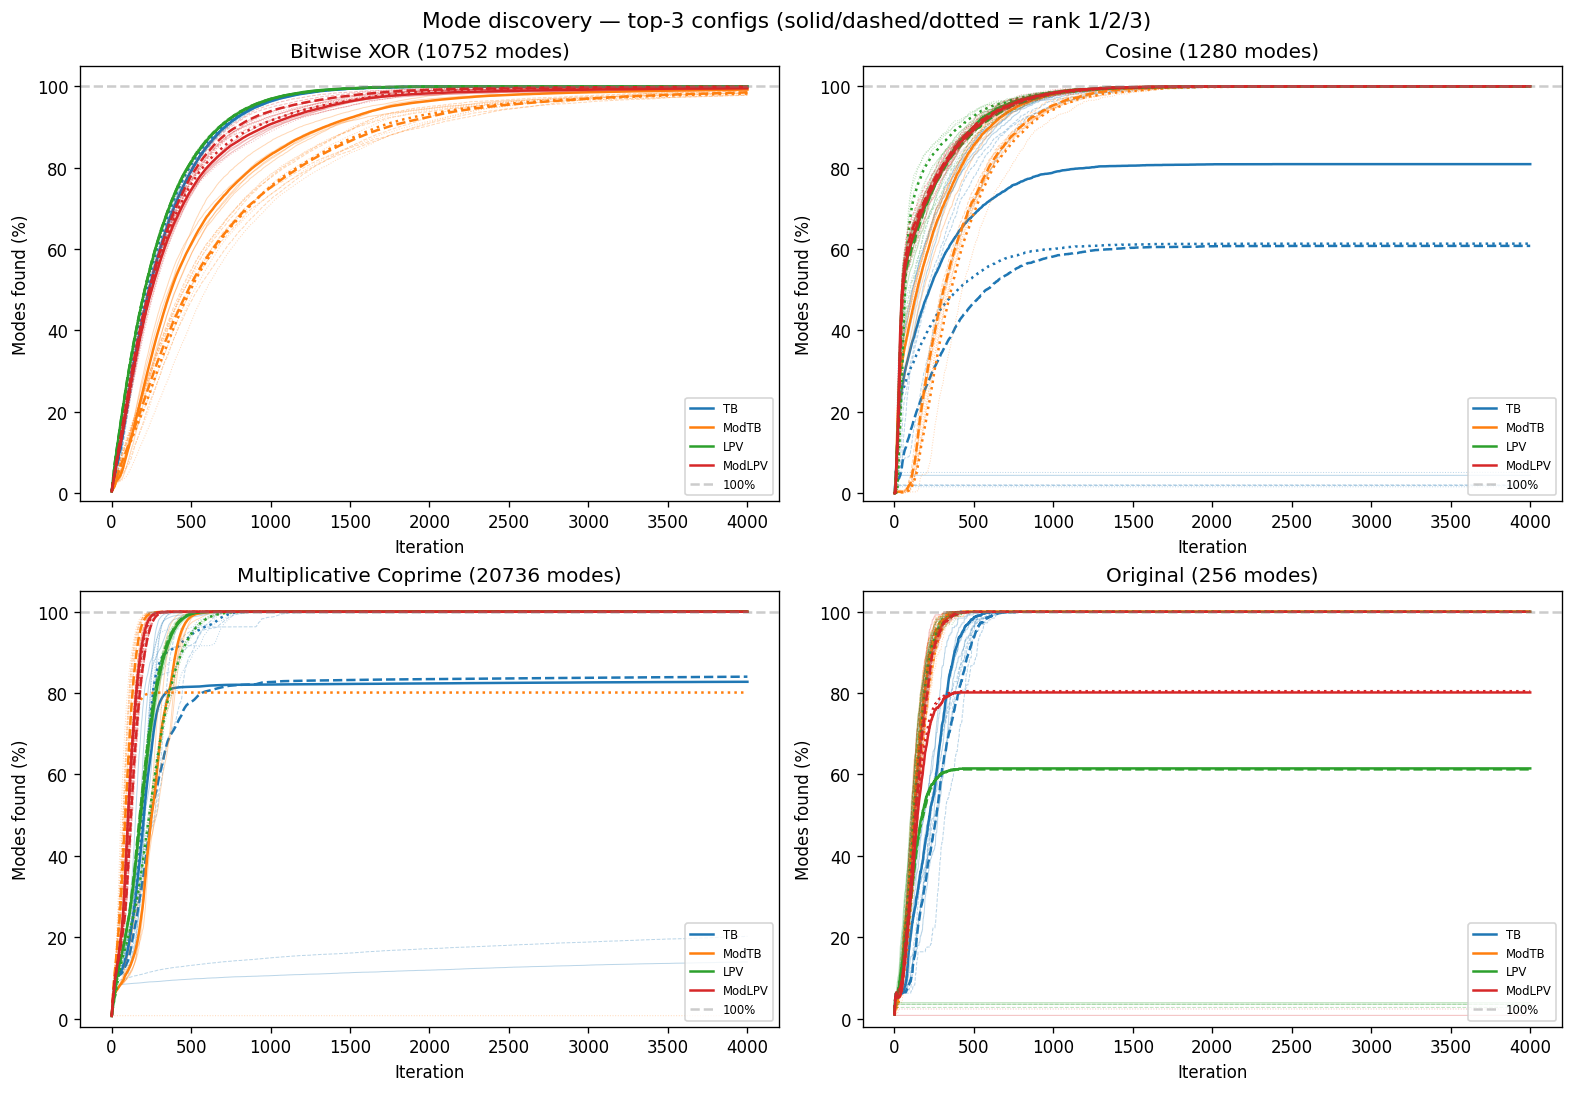

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, env in zip(axes.flat, env_list):
    env_data = ts[ts["environment"] == env]
    total_modes = env_data["total_mode_states"].dropna().iloc[0] if not env_data.empty else None

    for algo in ALGO_ORDER:
        for rank in [1, 2, 3]:
            ad = env_data[(env_data["algo"] == algo) & (env_data["rank"] == rank)]
            if ad.empty:
                continue
            # Individual seed traces
            for seed in ad["seed"].unique():
                seed_data = ad[ad["seed"] == seed].sort_values("iteration")
                pct = seed_data["n_mode_states_found"] / total_modes * 100 if total_modes else seed_data["n_mode_states_found"]
                ax.plot(seed_data["iteration"], pct,
                        color=COLORS[algo], linestyle=RANK_STYLES[rank],
                        alpha=0.3 * RANK_ALPHAS[rank], linewidth=0.6)
            # Mean trace
            grouped = ad.groupby("iteration")["n_mode_states_found"].mean()
            pct_mean = grouped / total_modes * 100 if total_modes else grouped
            label = algo if rank == 1 else None
            ax.plot(pct_mean.index, pct_mean.values,
                    label=label, color=COLORS[algo],
                    linestyle=RANK_STYLES[rank], alpha=RANK_ALPHAS[rank], linewidth=1.5)
    ax.axhline(100, ls="--", color="gray", alpha=0.4, label="100%")
    title_suffix = f" ({int(total_modes)} modes)" if total_modes else ""
    ax.set_title(f"{ENV_NAMES[env]}{title_suffix}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Modes found (%)")
    ax.set_ylim(-2, 105)
    ax.legend(loc="lower right")

fig.suptitle("Mode discovery — top-3 configs (solid/dashed/dotted = rank 1/2/3)", fontsize=13)
plt.show()

## Loss over training (comparable scale)

For Modified algorithms, we use `loss_unnormalized` (the standard TB/LPV loss before normalization), so all four algorithms are on the same loss scale within each environment.

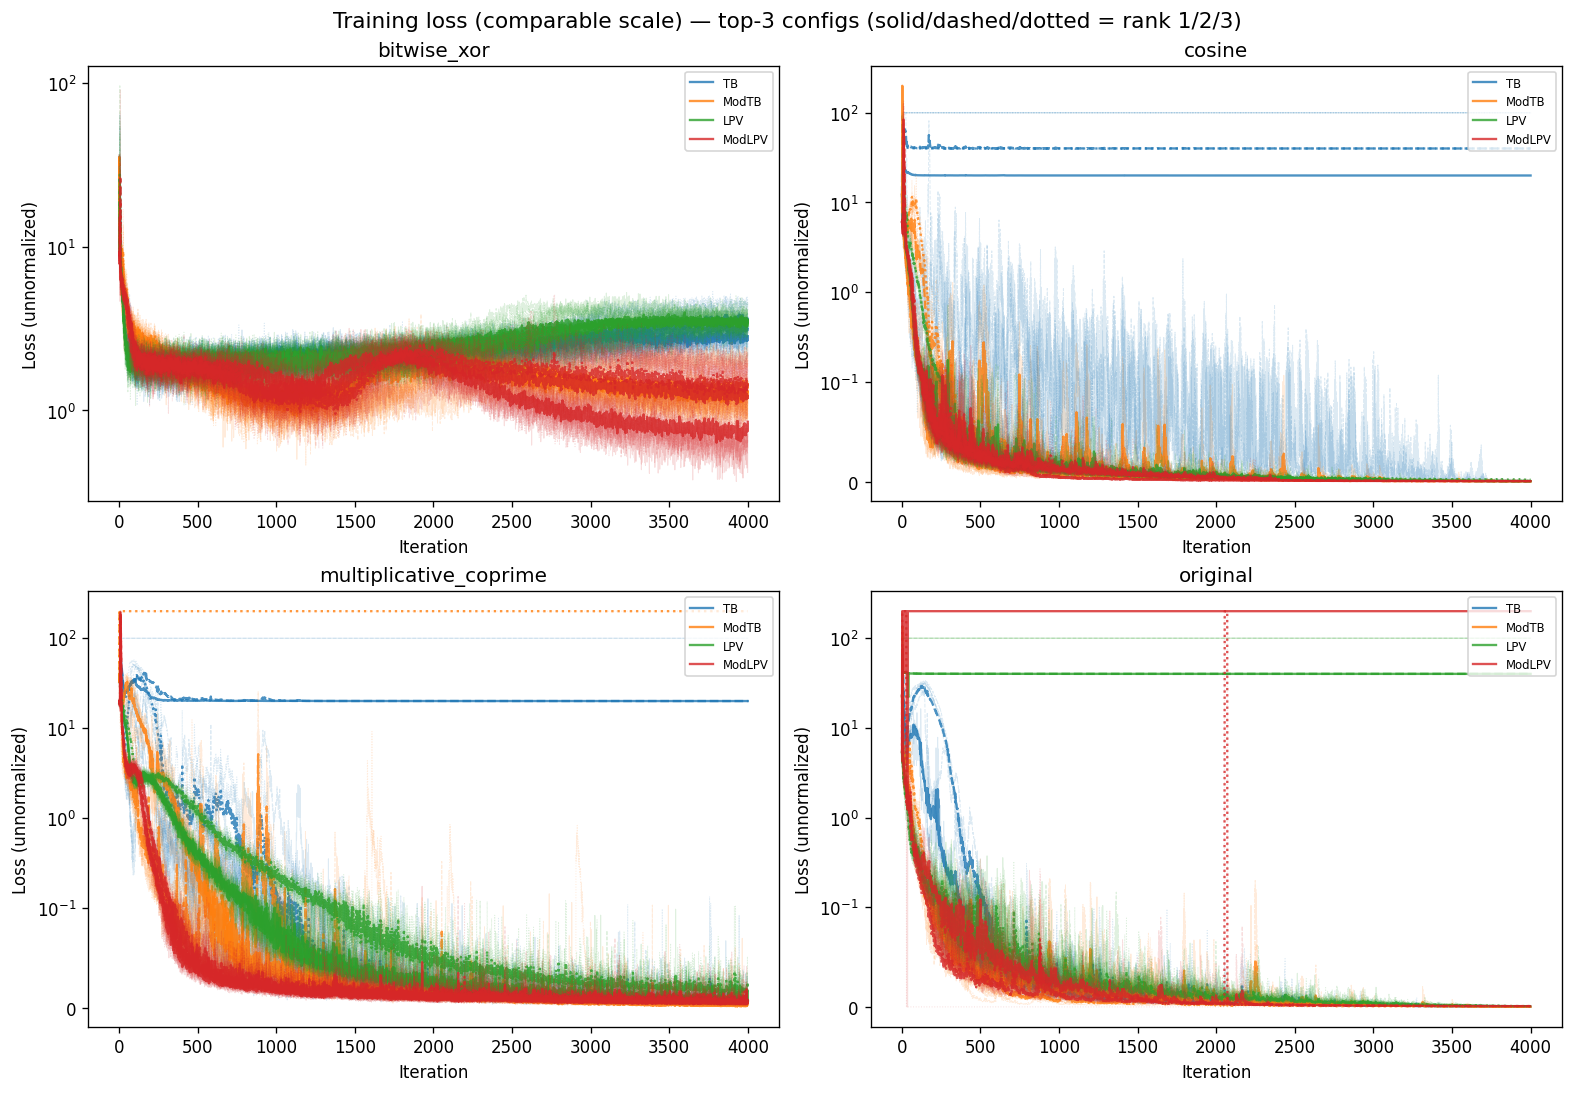

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, env in zip(axes.flat, env_list):
    for algo in ALGO_ORDER:
        for rank in [1, 2, 3]:
            ad = ts[(ts["environment"] == env) & (ts["algo"] == algo) & (ts["rank"] == rank)]
            if ad.empty:
                continue
            # Individual seed traces
            for seed in ad["seed"].unique():
                seed_data = ad[ad["seed"] == seed].sort_values("iteration")
                ax.plot(seed_data["iteration"], seed_data["comparable_loss"].clip(upper=200),
                        color=COLORS[algo], linestyle=RANK_STYLES[rank],
                        alpha=0.15 * RANK_ALPHAS[rank], linewidth=0.6)
            # Mean trace
            grouped = ad.groupby("iteration")["comparable_loss"].mean()
            clipped_mean = grouped.clip(upper=200)
            label = algo if rank == 1 else None
            ax.plot(clipped_mean.index, clipped_mean.values,
                    label=label, color=COLORS[algo],
                    linestyle=RANK_STYLES[rank], alpha=RANK_ALPHAS[rank] * 0.8, linewidth=1.4)
    ax.set_title(env)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss (unnormalized)")
    ax.set_yscale("symlog", linthresh=0.1)
    ax.legend(loc="upper right")

fig.suptitle("Training loss (comparable scale) — top-3 configs (solid/dashed/dotted = rank 1/2/3)", fontsize=13)
plt.show()

## JSD over training (top-3 configs)

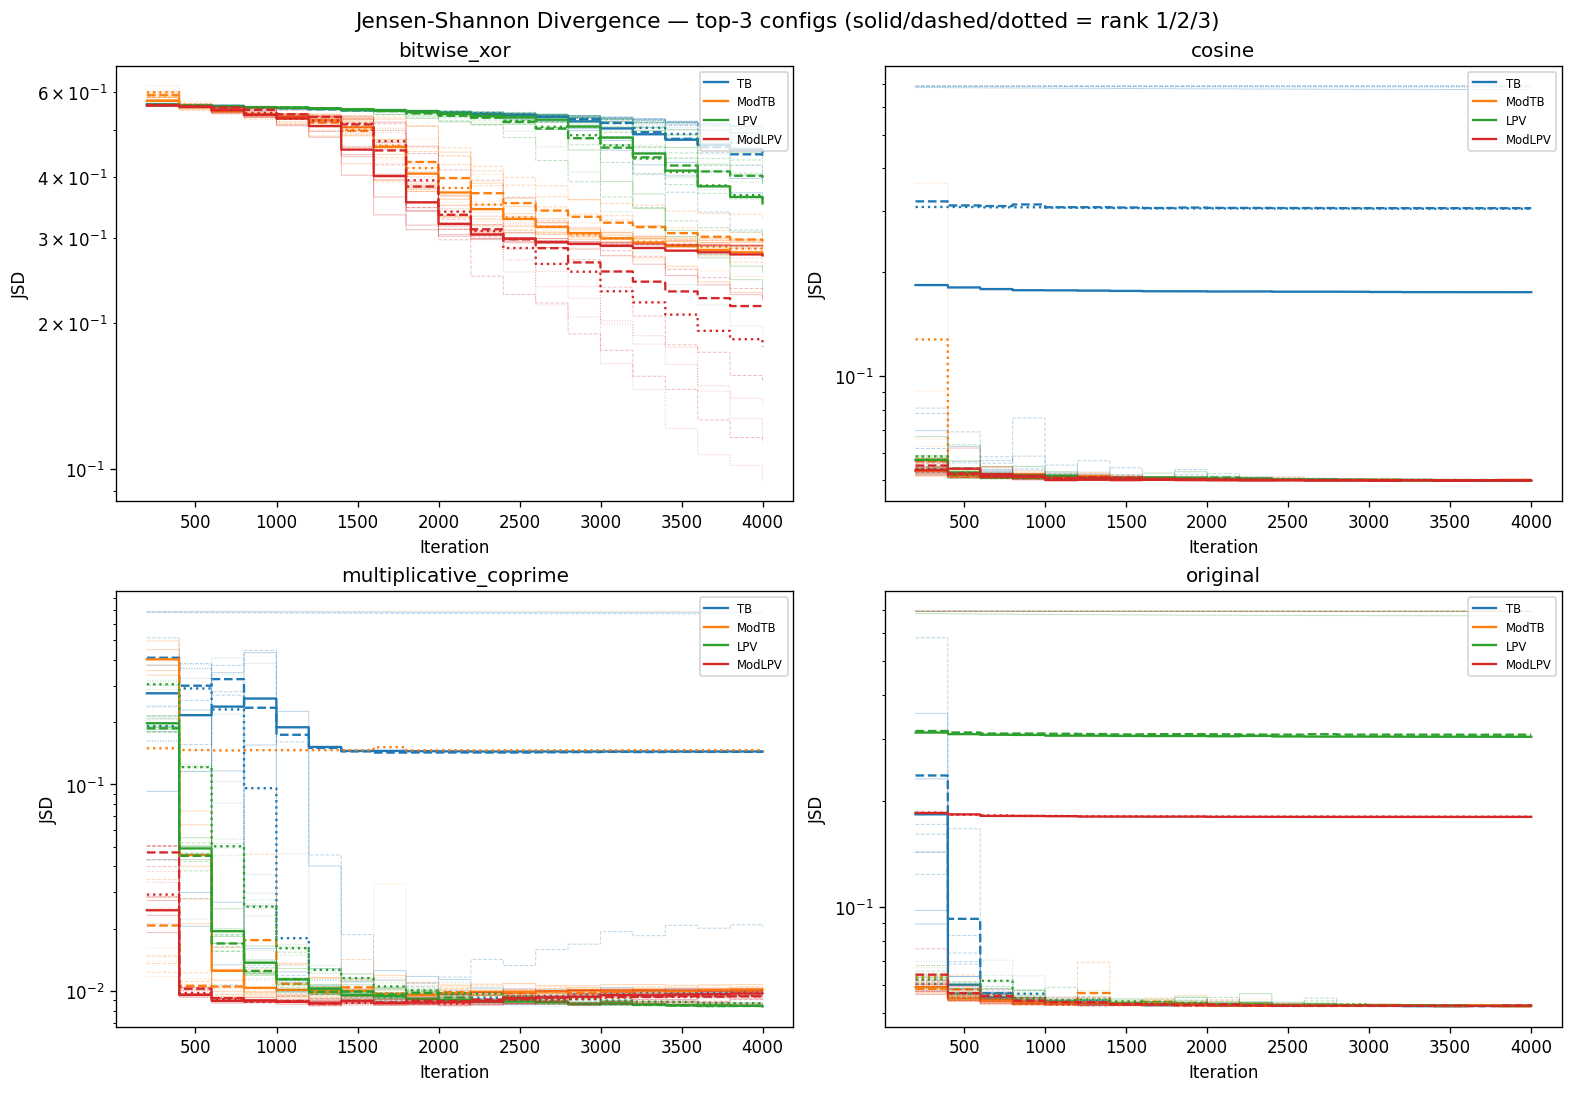

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, env in zip(axes.flat, env_list):
    for algo in ALGO_ORDER:
        for rank in [1, 2, 3]:
            ad = ts[(ts["environment"] == env) & (ts["algo"] == algo) & (ts["rank"] == rank)]
            ad = ad[ad["jsd_finite"].notna()]
            if ad.empty:
                continue
            # Individual seed traces
            for seed in ad["seed"].unique():
                seed_data = ad[ad["seed"] == seed].sort_values("iteration")
                seed_jsd = seed_data[seed_data["jsd_finite"].notna()]
                ax.plot(seed_jsd["iteration"], seed_jsd["jsd_finite"],
                        color=COLORS[algo], linestyle=RANK_STYLES[rank],
                        alpha=0.3 * RANK_ALPHAS[rank], linewidth=0.6)
            # Mean trace
            grouped = ad.groupby("iteration")["jsd_finite"].mean()
            label = algo if rank == 1 else None
            ax.plot(grouped.index, grouped.values,
                    label=label, color=COLORS[algo],
                    linestyle=RANK_STYLES[rank], alpha=RANK_ALPHAS[rank], linewidth=1.4)
    ax.set_title(env)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("JSD")
    ax.set_yscale("log")
    ax.legend(loc="upper right")

fig.suptitle("Jensen-Shannon Divergence — top-3 configs (solid/dashed/dotted = rank 1/2/3)", fontsize=13)
plt.show()

## Final metrics summary (rank-1 config, iteration 4000)

End-of-training metrics averaged across 5 seeds, with color gradient highlighting best/worst per column.

In [15]:
# Get final iteration data for rank-1 configs
ts_rank1 = ts[ts["rank"] == 1]
final = ts_rank1.groupby(["environment", "algo", "seed"]).tail(1).copy()
final["mode_pct"] = final["n_mode_states_found"] / final["total_mode_states"] * 100

final_summary = (
    final.groupby(["environment", "algo"])
    .agg(
        l1_mean=("l1_finite", "mean"),
        l1_std=("l1_finite", "std"),
        jsd_mean=("jsd_finite", "mean"),
        jsd_std=("jsd_finite", "std"),
        mode_pct_mean=("mode_pct", "mean"),
        mode_pct_std=("mode_pct", "std"),
        loss_mean=("comparable_loss", "mean"),
        loss_std=("comparable_loss", "std"),
    )
    .reset_index()
)
final_summary["algo"] = pd.Categorical(final_summary["algo"], categories=ALGO_ORDER, ordered=True)
final_summary = final_summary.sort_values(["environment", "algo"])

final_summary.style.format({
    "l1_mean": "{:.4f}", "l1_std": "{:.4f}",
    "jsd_mean": "{:.4f}", "jsd_std": "{:.4f}",
    "mode_pct_mean": "{:.1f}%", "mode_pct_std": "{:.1f}%",
    "loss_mean": "{:.4f}", "loss_std": "{:.4f}",
}, na_rep="—").background_gradient(subset=["l1_mean"], cmap="RdYlGn_r")

,environment,algo,l1_mean,l1_std,jsd_mean,jsd_std,mode_pct_mean,mode_pct_std,loss_mean,loss_std
3,bitwise_xor,TB,1.6609,0.1603,0.4510,0.0670,100.0%,0.0%,2.8307,0.4055
2,bitwise_xor,ModTB,1.1985,0.0745,0.2772,0.0308,99.2%,0.5%,1.2733,0.5433
0,bitwise_xor,LPV,1.3769,0.2859,0.3529,0.1028,100.0%,0.0%,3.2916,0.3849
1,bitwise_xor,ModLPV,1.2099,0.0576,0.2757,0.0289,99.6%,0.3%,0.8528,0.4029
7,cosine,TB,0.7540,0.6837,0.1752,0.2800,80.9%,42.8%,20.0002,44.7213
6,cosine,ModTB,0.4484,0.0008,0.0500,0.0001,100.0%,0.0%,0.0003,0.0001
4,cosine,LPV,0.4479,0.0004,0.0499,0.0000,100.0%,0.0%,0.0004,0.0000
5,cosine,ModLPV,0.4480,0.0003,0.0499,0.0000,100.0%,0.0%,0.0005,0.0000
11,multiplicative_coprime,TB,0.5076,0.8279,0.1446,0.3015,82.8%,38.5%,20.0073,44.7173
10,multiplicative_coprime,ModTB,0.1381,0.0018,0.0101,0.0004,100.0%,0.0%,0.0050,0.0050


## Algorithm ranking summary

Rank (1=best, 4=worst) on L1, JSD, and mode coverage across all environments. Green = strength, red = weakness.

/var/folders/hd/jqxc7ns56l35q_zyk7xmptmw0000gn/T/ipykernel_9233/1580359467.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_mean = final_summary.pivot_table(index="environment", columns="algo", values=mean_col)
/var/folders/hd/jqxc7ns56l35q_zyk7xmptmw0000gn/T/ipykernel_9233/1580359467.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_std = final_summary.pivot_table(index="environment", columns="algo", values=std_col)
/var/folders/hd/jqxc7ns56l35q_zyk7xmptmw0000gn/T/ipykernel_9233/1580359467.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=Fals

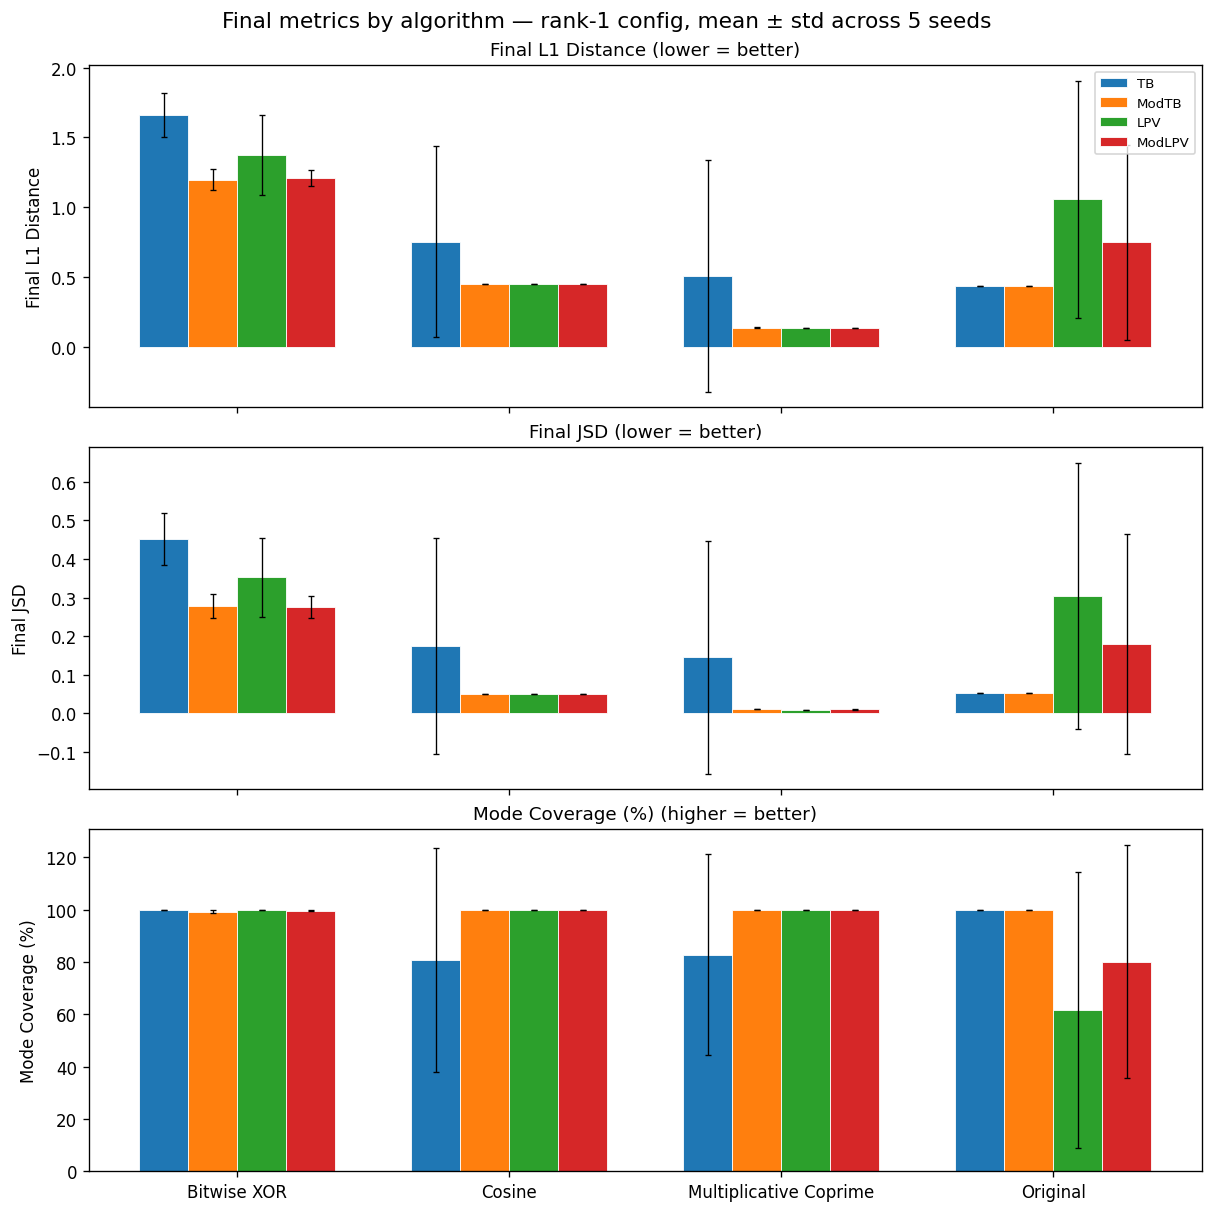

In [27]:
# Grouped bar charts: raw metric values with error bars (rank-1 config, 5 seeds)
metrics = [
    ("l1_mean", "l1_std", "Final L1 Distance", True),    # lower = better
    ("jsd_mean", "jsd_std", "Final JSD", True),           # lower = better
    ("mode_pct_mean", "mode_pct_std", "Mode Coverage (%)", False),  # higher = better
]

n_algos = len(ALGO_ORDER)
fig, axes = plt.subplots(len(metrics), 1, figsize=(10, 10), sharex=True)

env_labels = [ENV_NAMES.get(e, e) for e in sorted(final_summary["environment"].unique())]
x = np.arange(len(env_labels))
bar_width = 0.18
offsets = np.arange(n_algos) - (n_algos - 1) / 2

for ax, (mean_col, std_col, title, lower_better) in zip(axes, metrics):
    pivot_mean = final_summary.pivot_table(index="environment", columns="algo", values=mean_col)
    pivot_std = final_summary.pivot_table(index="environment", columns="algo", values=std_col)
    pivot_mean = pivot_mean[ALGO_ORDER].rename(index=ENV_NAMES)
    pivot_std = pivot_std[ALGO_ORDER].rename(index=ENV_NAMES)

    for i, algo in enumerate(ALGO_ORDER):
        ax.bar(x + offsets[i] * bar_width, pivot_mean[algo],
               width=bar_width, color=COLORS[algo], label=algo,
               edgecolor="white", linewidth=0.5)
        ax.errorbar(x + offsets[i] * bar_width, pivot_mean[algo],
                    yerr=pivot_std[algo], fmt="none", ecolor="black",
                    capsize=2, capthick=0.8, linewidth=0.8)

    ax.set_ylabel(title)
    ax.set_title(title + (" (lower = better)" if lower_better else " (higher = better)"), fontsize=11)
    if ax == axes[0]:
        ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(env_labels)

fig.suptitle("Final metrics by algorithm — rank-1 config, mean ± std across 5 seeds", fontsize=13)
plt.show()

## Hyperparameters of selected configs

The Optuna-selected hyperparameters for the rank-1 config of each algorithm × environment.

In [17]:
# Extract HP values for rank-1 configs
hp_detail = ts_rank1.groupby(["environment", "algo"]).first()[HP_COLS + ["lr_logz_multiplier"]].reset_index()
hp_detail["algo"] = pd.Categorical(hp_detail["algo"], categories=ALGO_ORDER, ordered=True)
hp_detail = hp_detail.sort_values(["environment", "algo"])

hp_detail.style.format({
    "lr": "{:.2e}",
    "beta2": "{:.4f}",
    "grad_clip_max_norm": "{:.4f}",
    "lr_logz_multiplier": "{:.2f}",
}, na_rep="—")

,environment,algo,lr,beta2,grad_clip_max_norm,lr_logz_multiplier
3,bitwise_xor,TB,4.81e-03,0.9999,0.1610,151.05
2,bitwise_xor,ModTB,7.01e-03,0.9999,1.1180,876.97
0,bitwise_xor,LPV,5.81e-03,0.9999,0.0210,1.00
1,bitwise_xor,ModLPV,7.28e-03,0.9990,3.1526,1.00
7,cosine,TB,3.67e-03,0.9900,0.4064,335.45
6,cosine,ModTB,1.11e-02,0.9900,0.1703,148.73
4,cosine,LPV,1.70e-03,0.9999,0.1894,1.00
5,cosine,ModLPV,2.18e-03,0.9999,0.0534,1.00
11,multiplicative_coprime,TB,1.59e-03,0.9990,1.9469,95.53
10,multiplicative_coprime,ModTB,2.46e-03,0.9900,0.0137,44.74


## Hyperparameter landscape from Optuna search

Each point is one completed Optuna trial, colored by algorithm. The y-axis shows the search objective (L1 distance — lower is better). This reveals how each algorithm's optimal HP region differs, and where boundary pressure exists in the search space.

In [18]:
import sqlite3

# --- Load all completed trials from Optuna DBs ---
db_dir = Path("optuna_results/db")
BETA2_MAP = {0.0: 0.99, 1.0: 0.999, 2.0: 0.9999}

optuna_frames = []
for dbfile in sorted(db_dir.glob("*.db")):
    algo_raw, env = dbfile.stem.split("__")
    algo = ALGO_SHORT[algo_raw]
    conn = sqlite3.connect(str(dbfile))
    trials = pd.read_sql("SELECT trial_id, state FROM trials", conn)
    params = pd.read_sql("SELECT trial_id, param_name, param_value FROM trial_params", conn)
    values = pd.read_sql("SELECT trial_id, value FROM trial_values", conn)
    conn.close()
    param_wide = params.pivot(index="trial_id", columns="param_name", values="param_value")
    merged = trials.merge(param_wide, on="trial_id", how="left")
    merged = merged.merge(values, on="trial_id", how="left")
    merged["algo"] = algo
    merged["environment"] = env
    optuna_frames.append(merged)

optuna = pd.concat(optuna_frames, ignore_index=True)
optuna = optuna[optuna["state"] == "COMPLETE"].copy()
for col in ["lr", "grad_clip", "lr_logz_multiplier", "beta2", "value"]:
    if col in optuna.columns:
        optuna[col] = pd.to_numeric(optuna[col], errors="coerce")
optuna["beta2"] = optuna["beta2"].map(BETA2_MAP)
optuna["eff_lr_logz"] = optuna["lr"] * optuna["lr_logz_multiplier"]

print(f"Loaded {len(optuna)} completed Optuna trials across {optuna['algo'].nunique()} algorithms, "
      f"{optuna['environment'].nunique()} environments")

Loaded 743 completed Optuna trials across 4 algorithms, 4 environments


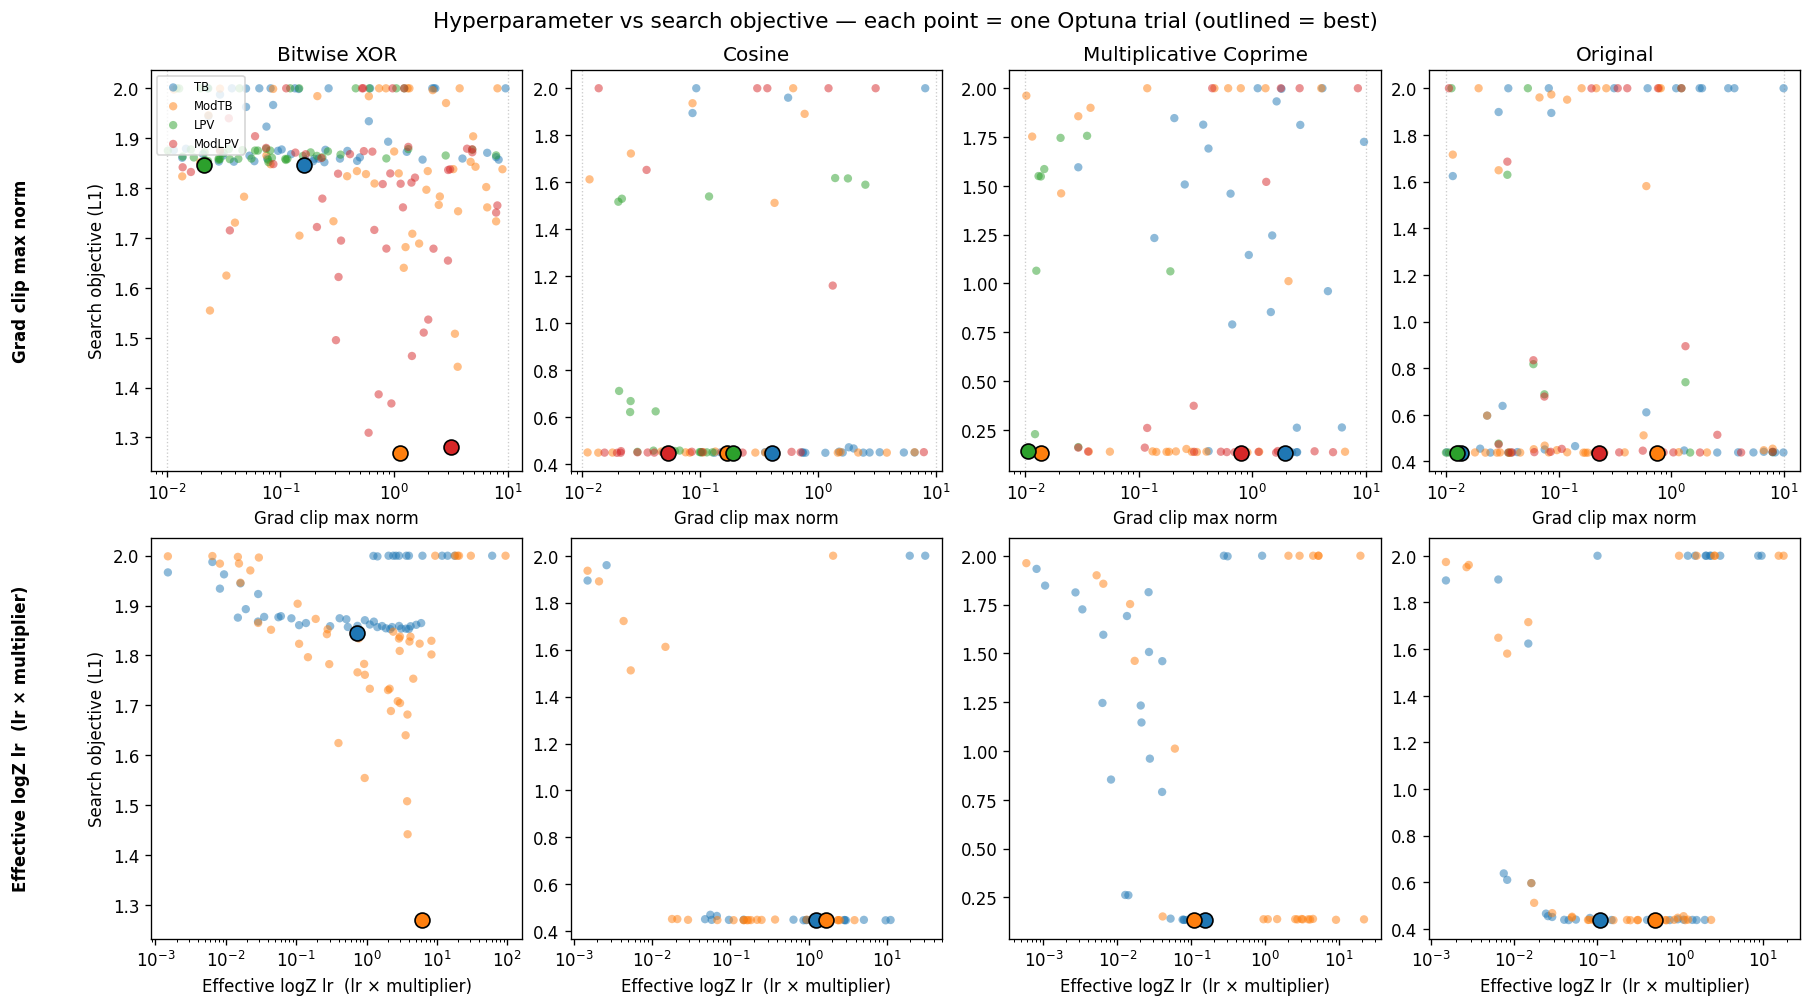

In [19]:
hp_rows = [
    ("grad_clip", "Grad clip max norm", True,
     dict(low=0.01, high=10.0)),
    ("eff_lr_logz", "Effective logZ lr  (lr × multiplier)", True,
     None),  # TB/ModTB only
]

fig, axes = plt.subplots(len(hp_rows), len(env_list), figsize=(15, 4 * len(hp_rows)),
                         squeeze=False)

for row_idx, (hp_col, hp_label, use_log, search_range) in enumerate(hp_rows):
    for col_idx, env in enumerate(env_list):
        ax = axes[row_idx, col_idx]
        for algo in ALGO_ORDER:
            sub = optuna[(optuna["environment"] == env) & (optuna["algo"] == algo)]
            if hp_col not in sub.columns or sub[hp_col].isna().all():
                continue
            sub = sub.dropna(subset=[hp_col, "value"])
            if sub.empty:
                continue
            ax.scatter(sub[hp_col], sub["value"],
                       color=COLORS[algo], label=algo,
                       alpha=0.5, s=25, edgecolors="none")
            # Mark the best trial
            best = sub.loc[sub["value"].idxmin()]
            ax.scatter(best[hp_col], best["value"],
                       color=COLORS[algo], s=80, edgecolors="black",
                       linewidths=1.0, zorder=5)
        if use_log:
            ax.set_xscale("log")
        # Shade search boundaries
        if search_range is not None:
            ax.axvline(search_range["low"], color="gray", ls=":", alpha=0.4, linewidth=0.8)
            ax.axvline(search_range["high"], color="gray", ls=":", alpha=0.4, linewidth=0.8)
        ax.set_title(ENV_NAMES.get(env, env) if row_idx == 0 else "")
        ax.set_xlabel(hp_label) #if row_idx == len(hp_rows) - 1 else "")
        ax.set_ylabel("Search objective (L1)" if col_idx == 0 else "")
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=7, loc="upper left")
        # Label the row on the left margin
        if col_idx == 0:
            ax.annotate(hp_label, xy=(-0.35, 0.5), xycoords="axes fraction",
                        fontsize=10, fontweight="bold", ha="center", va="center",
                        rotation=90)

fig.suptitle("Hyperparameter vs search objective — each point = one Optuna trial (outlined = best)",
             fontsize=13, y=1.03)
plt.show()

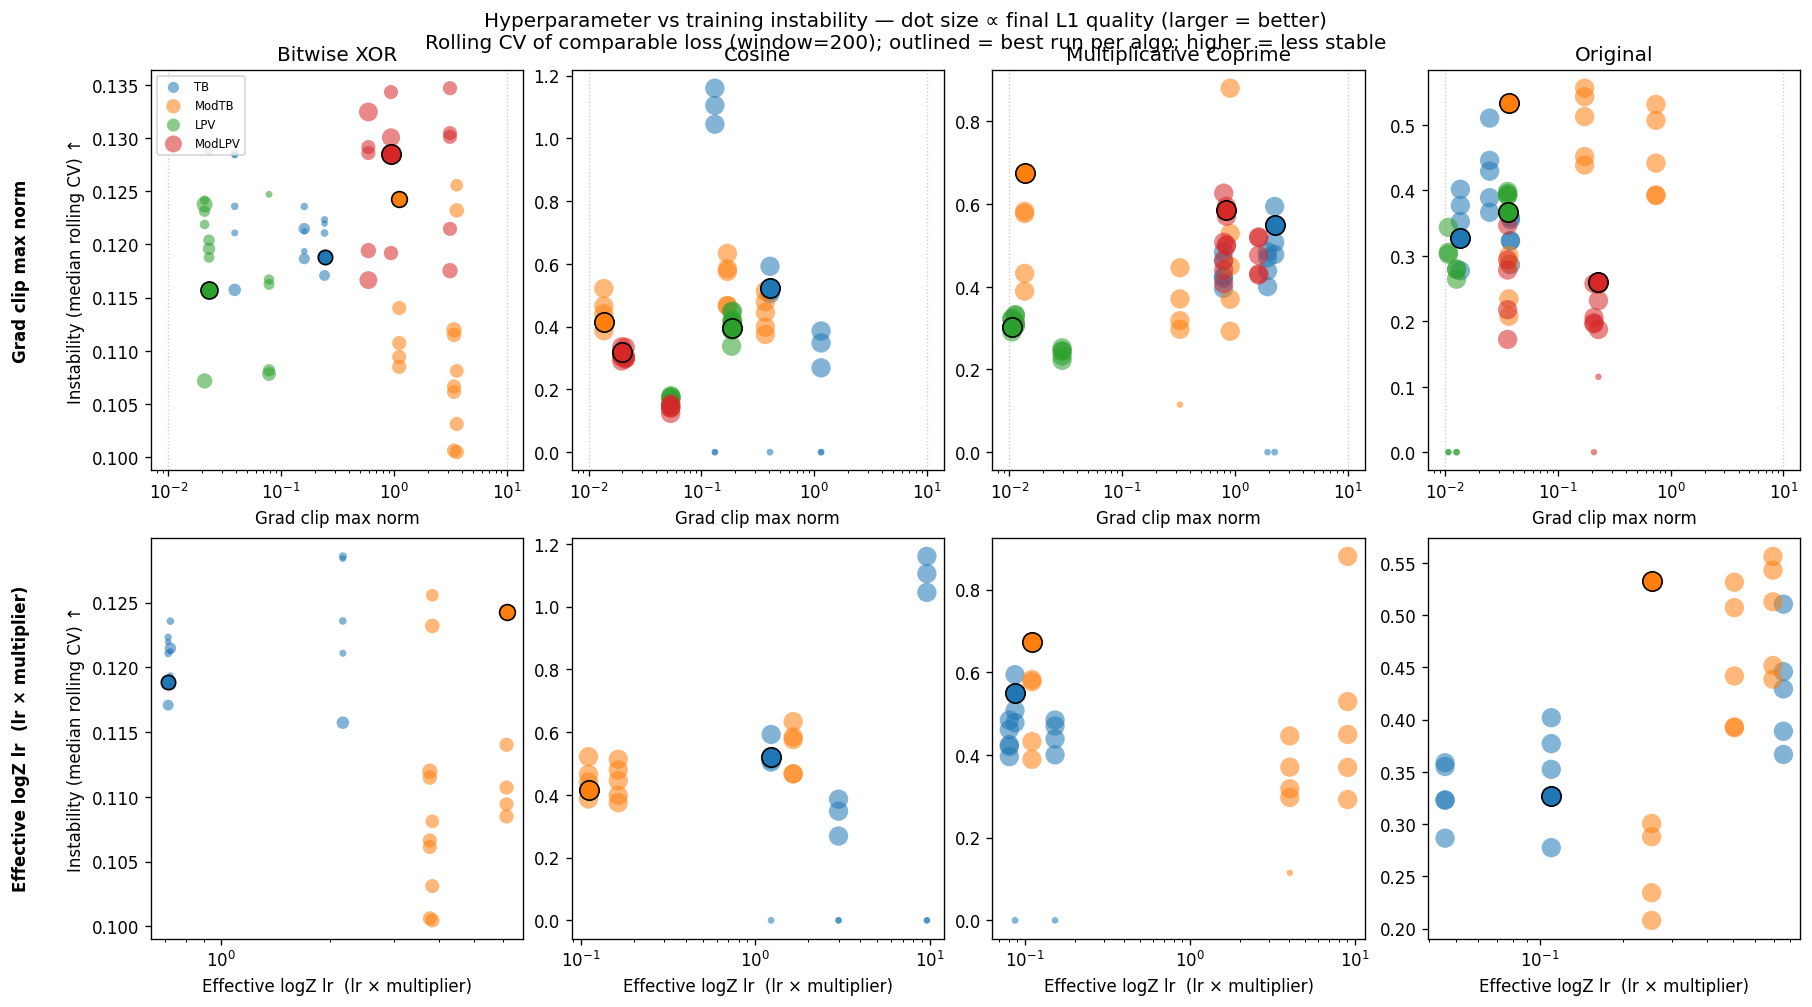

In [20]:
# Hyperparameter vs training stability (rolling CV of comparable loss)
# One point per (algo, env, rank, seed) confirmation run

# --- Compute per-run stability metric ---
window = 200  # rolling window size for CV computation
stability_rows = []

for keys, group in ts.groupby(["environment", "algo", "rank", "seed"]):
    env, algo, rank, seed = keys
    g = group.sort_values("iteration")
    loss = g["comparable_loss"].values
    # Rolling CV = rolling_std / rolling_mean (coefficient of variation)
    s = pd.Series(loss)
    roll_mean = s.rolling(window, min_periods=window // 2).mean()
    roll_std = s.rolling(window, min_periods=window // 2).std()
    roll_cv = (roll_std / roll_mean.abs().clip(lower=1e-8))
    # Summarise as median rolling CV over the run
    median_cv = roll_cv.median()
    best_l1 = g["l1_finite"].min()
    stability_rows.append({
        "environment": env, "algo": algo, "rank": rank, "seed": seed,
        "stability_cv": median_cv,
        "best_l1": best_l1,
        "lr": g["lr"].iloc[0],
        "grad_clip_max_norm": g["grad_clip_max_norm"].iloc[0],
        "lr_logz_multiplier": g["lr_logz_multiplier"].iloc[0],
    })

stab = pd.DataFrame(stability_rows)
stab["eff_lr_logz"] = stab["lr"] * stab["lr_logz_multiplier"]

# --- Plot ---
hp_rows = [
    ("grad_clip_max_norm", "Grad clip max norm", True,
     dict(low=0.01, high=10.0), ALGO_ORDER),
    ("eff_lr_logz", "Effective logZ lr  (lr × multiplier)", True,
     None, ["TB", "ModTB"]),  # Only TB/ModTB have a logZ optimizer
]

fig, axes = plt.subplots(len(hp_rows), len(env_list),
                         figsize=(15, 4 * len(hp_rows)), squeeze=False)

for row_idx, (hp_col, hp_label, use_log, search_range, algos) in enumerate(hp_rows):
    for col_idx, env in enumerate(env_list):
        ax = axes[row_idx, col_idx]
        env_data = stab[stab["environment"] == env].dropna(subset=[hp_col, "stability_cv", "best_l1"])

        # Min-max normalise best_l1 within this subplot for dot sizing
        if env_data.empty:
            continue
        l1_vals = env_data["best_l1"]
        l1_min, l1_max = l1_vals.min(), l1_vals.max()
        if l1_max > l1_min:
            l1_norm = (l1_vals - l1_min) / (l1_max - l1_min)
        else:
            l1_norm = pd.Series(0.5, index=l1_vals.index)
        # Map to dot sizes: best (0) = large, worst (1) = small
        sizes = 15 + 120 * (1 - l1_norm)

        for algo in algos:
            sub = env_data[env_data["algo"] == algo]
            if sub.empty or sub[hp_col].isna().all():
                continue
            idx = sub.index
            ax.scatter(sub[hp_col], sub["stability_cv"],
                       color=COLORS[algo], label=algo,
                       s=sizes.loc[idx], alpha=0.55, edgecolors="none")
            # Highlight best run (lowest L1) for this algo in this env
            best_idx = sub["best_l1"].idxmin()
            ax.scatter(sub.loc[best_idx, hp_col], sub.loc[best_idx, "stability_cv"],
                       color=COLORS[algo], s=sizes.loc[best_idx],
                       edgecolors="black", linewidths=1.0, zorder=5)

        if use_log:
            ax.set_xscale("log")
        if search_range is not None:
            ax.axvline(search_range["low"], color="gray", ls=":", alpha=0.4, linewidth=0.8)
            ax.axvline(search_range["high"], color="gray", ls=":", alpha=0.4, linewidth=0.8)
        ax.set_title(ENV_NAMES.get(env, env) if row_idx == 0 else "")
        ax.set_xlabel(hp_label)
        ax.set_ylabel("Instability (median rolling CV) ↑" if col_idx == 0 else "")
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=7, loc="upper left")
        if col_idx == 0:
            ax.annotate(hp_label, xy=(-0.35, 0.5), xycoords="axes fraction",
                        fontsize=10, fontweight="bold", ha="center", va="center",
                        rotation=90)

fig.suptitle("Hyperparameter vs training instability — dot size ∝ final L1 quality (larger = better)\n"
             "Rolling CV of comparable loss (window=200); outlined = best run per algo; higher = less stable",
             fontsize=12, y=1.03)
plt.show()

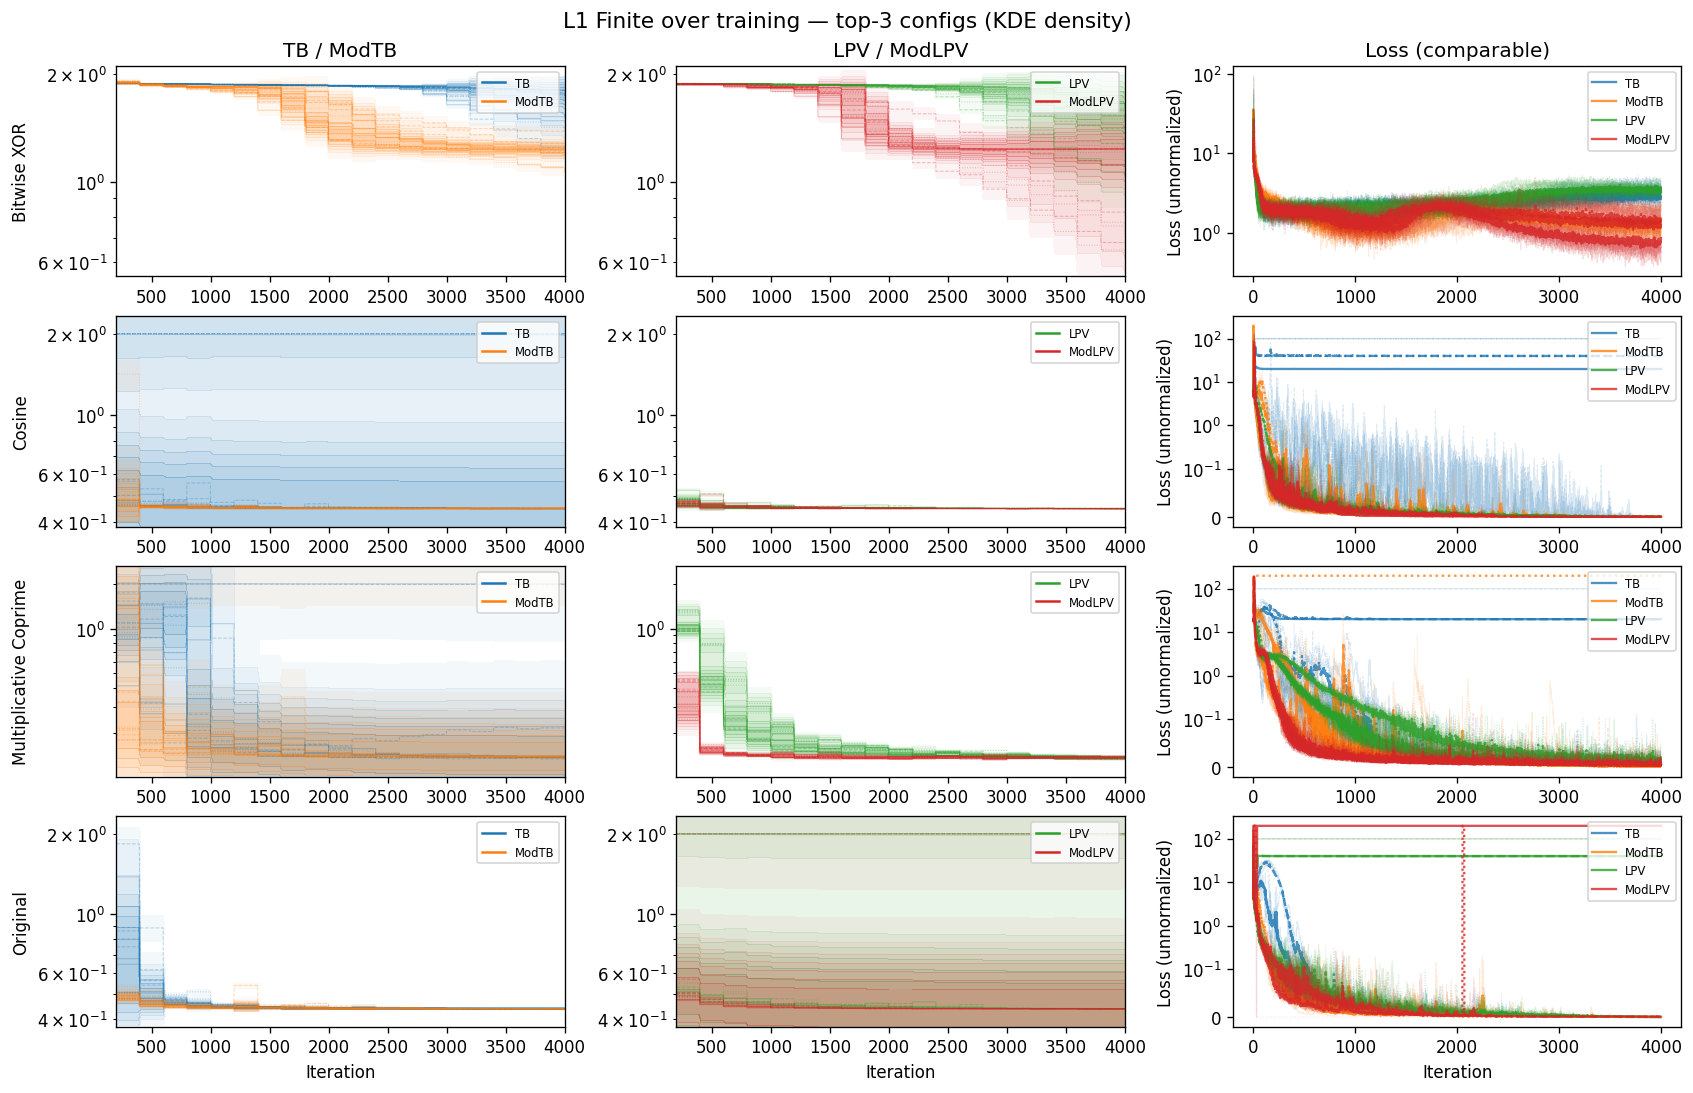

In [21]:
from scipy.stats import gaussian_kde
from matplotlib.colors import to_rgba

ALGO_GROUPS = [("TB", "ModTB"), ("LPV", "ModLPV")]
ALGO_GROUP_NAMES = ["TB / ModTB", "LPV / ModLPV"]

def plot_metric_over_time(ts, metric, n_ranks=3, kde=False, n_kde_points=200):

    n_cols = len(ALGO_GROUPS) + 1  # +1 for loss column
    fig, axes = plt.subplots(len(env_list), n_cols, figsize=(14, 9),
                             gridspec_kw={"width_ratios": [1, 1, 1]})

    for row_idx, env in enumerate(env_list):
        # --- Columns 0-1: metric split by algo group ---
        # Share y-axis within each row for the metric columns
        for col_idx in range(1, len(ALGO_GROUPS)):
            axes[row_idx, col_idx].sharey(axes[row_idx, 0])

        for col_idx, algo_group in enumerate(ALGO_GROUPS):
            ax = axes[row_idx, col_idx]

            assert 1 <= n_ranks <= 3, "Expected n_ranks to be between 1 and 3"

            for algo in algo_group:
                for rank in range(1, n_ranks + 1):
                    ad = ts[(ts["environment"] == env) & (ts["algo"] == algo) & (ts["rank"] == rank)]
                    ad = ad[ad[metric].notna()]
                    if ad.empty:
                        continue
                    for seed in ad["seed"].unique():
                        seed_data = ad[ad["seed"] == seed].sort_values("iteration")
                        ax.plot(seed_data["iteration"], seed_data[metric],
                                color=COLORS[algo], linestyle=RANK_STYLES[rank],
                                alpha=0.3 * RANK_ALPHAS[rank], linewidth=0.6)

                if kde:
                    ad_all = ts[(ts["environment"] == env) & (ts["algo"] == algo)
                                & (ts["rank"].isin(range(1, n_ranks + 1)))]
                    ad_all = ad_all[ad_all[metric].notna()]
                    if ad_all.empty:
                        continue
                    iterations = sorted(ad_all["iteration"].unique())
                    kde_iters = iterations[::max(1, len(iterations) // n_kde_points)]
                    log_vals_at_iter = []
                    for it in kde_iters:
                        vals = ad_all.loc[ad_all["iteration"] == it, metric].values
                        vals = vals[vals > 0]
                        log_vals_at_iter.append((it, np.log10(vals)))

                    all_log = np.concatenate([lv for _, lv in log_vals_at_iter])
                    y_min, y_max = all_log.min(), all_log.max()
                    pad = (y_max - y_min) * 0.1
                    y_grid = np.linspace(y_min - pad, y_max + pad, 150)

                    density_map = np.zeros((len(y_grid), len(kde_iters)))
                    for j, (it, lv) in enumerate(log_vals_at_iter):
                        if len(lv) < 2 or np.std(lv) < 1e-10:
                            continue
                        try:
                            kde_obj = gaussian_kde(lv)
                            density_map[:, j] = kde_obj(y_grid)
                        except np.linalg.LinAlgError:
                            continue

                    col_max = density_map.max(axis=0, keepdims=True)
                    col_max[col_max == 0] = 1
                    density_norm = density_map / col_max

                    base_color = to_rgba(COLORS[algo])
                    iter_arr = np.array(kde_iters)
                    ax.contourf(iter_arr, 10**y_grid, density_norm,
                                levels=np.linspace(0.05, 1.0, 8),
                                colors=[(*base_color[:3], a) for a in np.linspace(0.05, 0.4, 8)])
                else:
                    for rank in range(1, n_ranks + 1):
                        ad = ts[(ts["environment"] == env) & (ts["algo"] == algo) & (ts["rank"] == rank)]
                        ad = ad[ad[metric].notna()]
                        if ad.empty:
                            continue
                        grouped = ad.groupby("iteration")[metric].mean()
                        label = algo if rank == 1 else None
                        ax.plot(grouped.index, grouped.values,
                                label=label, color=COLORS[algo],
                                linestyle=RANK_STYLES[rank], alpha=RANK_ALPHAS[rank], linewidth=1.4)

                if kde:
                    ax.plot([], [], color=COLORS[algo], linewidth=1.5, label=algo)

            if row_idx == 0:
                ax.set_title(ALGO_GROUP_NAMES[col_idx])
            ax.set_xlabel("Iteration" if row_idx == len(env_list) - 1 else "")
            if col_idx == 0:
                ax.set_ylabel(ENV_NAMES[env])
            ax.set_yscale("log")
            ax.legend(loc="upper right", fontsize=7)

        # --- Column 2: comparable loss for all algos ---
        ax_loss = axes[row_idx, 2]
        for algo in ALGO_ORDER:
            for rank in range(1, n_ranks + 1):
                ad = ts[(ts["environment"] == env) & (ts["algo"] == algo) & (ts["rank"] == rank)]
                if ad.empty:
                    continue
                for seed in ad["seed"].unique():
                    seed_data = ad[ad["seed"] == seed].sort_values("iteration")
                    ax_loss.plot(seed_data["iteration"], seed_data["comparable_loss"].clip(upper=200),
                                 color=COLORS[algo], linestyle=RANK_STYLES[rank],
                                 alpha=0.15 * RANK_ALPHAS[rank], linewidth=0.6)
                grouped = ad.groupby("iteration")["comparable_loss"].mean()
                clipped_mean = grouped.clip(upper=200)
                label = algo if rank == 1 else None
                ax_loss.plot(clipped_mean.index, clipped_mean.values,
                             label=label, color=COLORS[algo],
                             linestyle=RANK_STYLES[rank], alpha=RANK_ALPHAS[rank] * 0.8, linewidth=1.4)

        if row_idx == 0:
            ax_loss.set_title("Loss (comparable)")
        ax_loss.set_xlabel("Iteration" if row_idx == len(env_list) - 1 else "")
        ax_loss.set_ylabel("Loss (unnormalized)")
        ax_loss.set_yscale("symlog", linthresh=0.1)
        ax_loss.legend(loc="upper right", fontsize=7)

    fig.align_ylabels(axes[:, 0])

    mode = "KDE density" if kde else "solid/dashed/dotted = rank 1/2/3"
    fig.suptitle(f"{metric.replace('_', ' ').title()} over training — top-{n_ranks} configs ({mode})", fontsize=13)
    plt.show()

plot_metric_over_time(ts, "l1_finite", 3, kde=True)

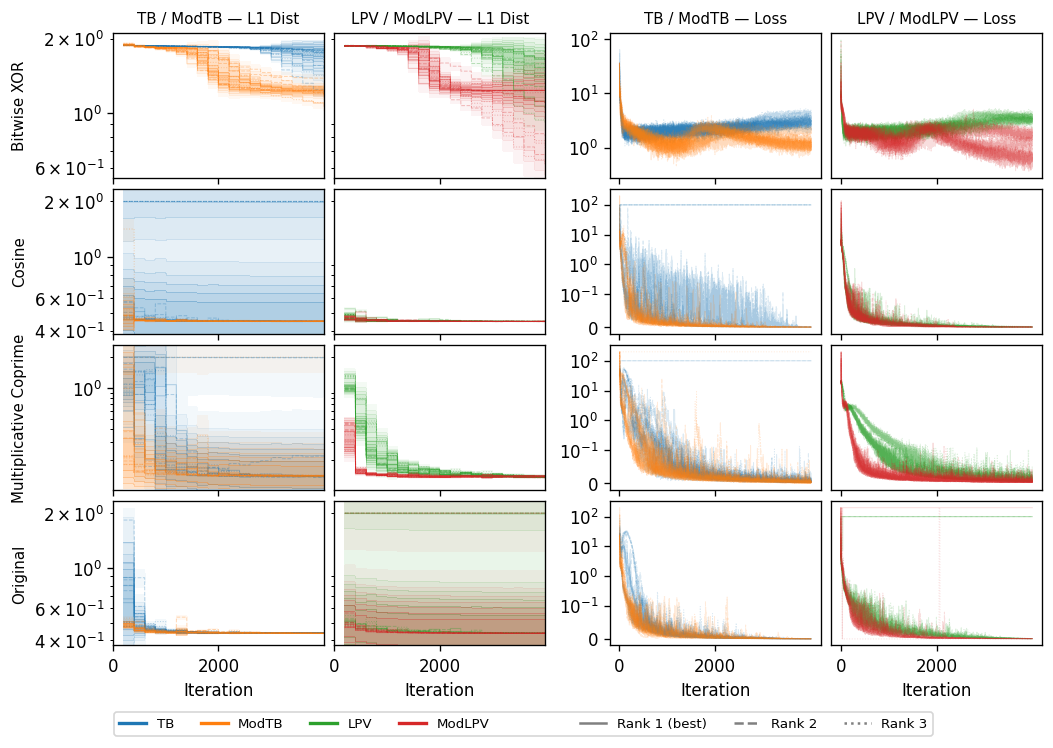

In [ ]:
# Layout B: 4 rows × 4 cols — [TB/ModTB score, LPV/ModLPV score, TB/ModTB loss, LPV/ModLPV loss]
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

def plot_metric_and_loss_4x4(ts, metric, n_ranks=3, kde=False, n_kde_points=200, plot_means=False):

    with plt.rc_context({"figure.constrained_layout.use": False}):
        fig = plt.figure(figsize=(9, 6))
        # Outer grid: 1 row × 2 cols (score pair | loss pair)
        outer = GridSpec(1, 2, figure=fig, wspace=0.15,
                         bottom=0.14, top=0.99, left=0.12, right=0.98)
        # Inner grids: 4 rows × 2 cols each, tight wspace
        gs_score = GridSpecFromSubplotSpec(len(env_list), 2, subplot_spec=outer[0],
                                           hspace=0.08, wspace=0.05)
        gs_loss = GridSpecFromSubplotSpec(len(env_list), 2, subplot_spec=outer[1],
                                          hspace=0.08, wspace=0.05)

        axes = np.empty((len(env_list), 4), dtype=object)
        for r in range(len(env_list)):
            axes[r, 0] = fig.add_subplot(gs_score[r, 0])
            axes[r, 1] = fig.add_subplot(gs_score[r, 1])
            axes[r, 2] = fig.add_subplot(gs_loss[r, 0])
            axes[r, 3] = fig.add_subplot(gs_loss[r, 1])

        x_ticks = [0, 2000]
        x_tick_labels = ["0", "2000"]

        if metric == "l1_finite":
            metric_label = "L1 Dist"
        elif metric == "jsd_finite":
            metric_label = "JSD"
        else:
            metric_label = metric.replace("_", " ").title()

        for row_idx, env in enumerate(env_list):
            for group_idx, algo_group in enumerate(ALGO_GROUPS):
                ax_metric = axes[row_idx, group_idx]          # cols 0, 1
                ax_loss = axes[row_idx, group_idx + 2]        # cols 2, 3

                for algo in algo_group:
                    # --- Metric traces ---
                    for rank in range(1, n_ranks + 1):
                        ad = ts[(ts["environment"] == env) & (ts["algo"] == algo) & (ts["rank"] == rank)]
                        ad = ad[ad[metric].notna()]
                        if ad.empty:
                            continue
                        for seed in ad["seed"].unique():
                            seed_data = ad[ad["seed"] == seed].sort_values("iteration")
                            ax_metric.plot(seed_data["iteration"], seed_data[metric],
                                           color=COLORS[algo], linestyle=RANK_STYLES[rank],
                                           alpha=0.3 * RANK_ALPHAS[rank], linewidth=0.6)

                    if kde:
                        ad_all = ts[(ts["environment"] == env) & (ts["algo"] == algo)
                                    & (ts["rank"].isin(range(1, n_ranks + 1)))]
                        ad_all = ad_all[ad_all[metric].notna()]
                        if not ad_all.empty:
                            iterations = sorted(ad_all["iteration"].unique())
                            kde_iters = iterations[::max(1, len(iterations) // n_kde_points)]
                            log_vals_at_iter = []
                            for it in kde_iters:
                                vals = ad_all.loc[ad_all["iteration"] == it, metric].values
                                vals = vals[vals > 0]
                                log_vals_at_iter.append((it, np.log10(vals)))
                            all_log = np.concatenate([lv for _, lv in log_vals_at_iter])
                            y_min, y_max = all_log.min(), all_log.max()
                            pad = (y_max - y_min) * 0.1
                            y_grid = np.linspace(y_min - pad, y_max + pad, 150)
                            density_map = np.zeros((len(y_grid), len(kde_iters)))
                            for j, (it, lv) in enumerate(log_vals_at_iter):
                                if len(lv) < 2 or np.std(lv) < 1e-10:
                                    continue
                                try:
                                    density_map[:, j] = gaussian_kde(lv)(y_grid)
                                except np.linalg.LinAlgError:
                                    continue
                            col_max = density_map.max(axis=0, keepdims=True)
                            col_max[col_max == 0] = 1
                            density_norm = density_map / col_max
                            base_color = to_rgba(COLORS[algo])
                            ax_metric.contourf(np.array(kde_iters), 10**y_grid, density_norm,
                                               levels=np.linspace(0.05, 1.0, 8),
                                               colors=[(*base_color[:3], a) for a in np.linspace(0.05, 0.4, 8)])

                    # --- Loss traces ---
                    for rank in range(1, n_ranks + 1):
                        ad = ts[(ts["environment"] == env) & (ts["algo"] == algo) & (ts["rank"] == rank)]
                        if ad.empty:
                            continue
                        for seed in ad["seed"].unique():
                            seed_data = ad[ad["seed"] == seed].sort_values("iteration")
                            ax_loss.plot(seed_data["iteration"], seed_data["comparable_loss"].clip(upper=200),
                                         color=COLORS[algo], linestyle=RANK_STYLES[rank],
                                         alpha=0.15 * RANK_ALPHAS[rank], linewidth=0.6)
                        if plot_means:
                            grouped = ad.groupby("iteration")["comparable_loss"].mean().clip(upper=200)
                            ax_loss.plot(grouped.index, grouped.values,
                                        color=COLORS[algo], linestyle=RANK_STYLES[rank],
                                        alpha=RANK_ALPHAS[rank] * 0.8, linewidth=1.4)

                # Metric formatting
                ax_metric.set_yscale("log")
                ax_metric.set_xticks(x_ticks)
                ax_metric.set_xticklabels(x_tick_labels if row_idx == len(env_list) - 1 else [])
                if row_idx == 0:
                    ax_metric.set_title(f"{ALGO_GROUP_NAMES[group_idx]} — {metric_label}", fontsize=9)
                if group_idx == 0:
                    ax_metric.set_ylabel(ENV_NAMES[env], fontsize=9)
                if row_idx < len(env_list) - 1:
                    ax_metric.tick_params(axis="x", labelbottom=False)
                else:
                    ax_metric.set_xlabel("Iteration")

                # Loss formatting
                ax_loss.set_yscale("symlog", linthresh=0.1)
                ax_loss.set_xticks(x_ticks)
                ax_loss.set_xticklabels(x_tick_labels if row_idx == len(env_list) - 1 else [])
                if row_idx == 0:
                    ax_loss.set_title(f"{ALGO_GROUP_NAMES[group_idx]} — Loss", fontsize=9)
                if row_idx < len(env_list) - 1:
                    ax_loss.tick_params(axis="x", labelbottom=False)
                else:
                    ax_loss.set_xlabel("Iteration")

        # Sync y-limits and hide tick labels on secondary col of each pair
        for row_idx in range(len(env_list)):
            for col_a, col_b in [(0, 1), (2, 3)]:
                ya = axes[row_idx, col_a].get_ylim()
                yb = axes[row_idx, col_b].get_ylim()
                shared = (min(ya[0], yb[0]), max(ya[1], yb[1]))
                axes[row_idx, col_a].set_ylim(shared)
                axes[row_idx, col_b].set_ylim(shared)
                axes[row_idx, col_b].yaxis.set_major_formatter(plt.NullFormatter())
                axes[row_idx, col_b].yaxis.set_minor_formatter(plt.NullFormatter())
                axes[row_idx, col_b].tick_params(axis="y", left=False)

        fig.align_ylabels([axes[r, 0] for r in range(len(env_list))])

        # Shared legend at the bottom
        legend_handles = []
        for algo in ALGO_ORDER:
            legend_handles.append(Line2D([0], [0], color=COLORS[algo], linewidth=2, label=algo))
        legend_handles.append(Line2D([0], [0], linewidth=0, label=""))
        rank_labels = {1: "Rank 1 (best)", 2: "Rank 2", 3: "Rank 3"}
        for rank in range(1, n_ranks + 1):
            legend_handles.append(Line2D([0], [0], color="gray", linewidth=1.5,
                                          linestyle=RANK_STYLES[rank], label=rank_labels[rank]))

        fig.legend(handles=legend_handles, loc="lower center",
                   ncol=len(ALGO_ORDER) + 1 + n_ranks, fontsize=8,
                   frameon=True, fancybox=True, shadow=False,
                   bbox_to_anchor=(0.5, 0.005))

        mode = "KDE" if kde else "mean"
        plt.savefig(f"outputs/metric_loss_4x4_{metric}_{'kde' if kde else 'mean'}.pdf", dpi=300, bbox_inches="tight")
        plt.show()

plot_metric_and_loss_4x4(ts, "l1_finite", 3, kde=True)